# 🧠 NLP Sentiment Analysis — Google Play Store Reviews

## Microsoft Teams Review Sentiment Analysis

**Notebook ini mencakup seluruh pipeline NLP Sentiment Analysis secara lengkap:**

| No | Tahap | Deskripsi |
|:--:|-------|----------|
| 1 | **Data Collection** | Scraping 10.000+ review dari Google Play Store |
| 2 | **Exploratory Data Analysis** | Analisis distribusi, statistik, dan pola data |
| 3 | **Sentiment Labeling** | Pelabelan otomatis berdasarkan rating |
| 4 | **NLP Preprocessing** | Text cleaning, tokenization, lemmatization |
| 5 | **Feature Extraction** | TF-IDF Vectorization |
| 6 | **Model Training** | Logistic Regression, Naive Bayes, Random Forest |
| 7 | **Model Evaluation** | Accuracy, Precision, Recall, F1, Confusion Matrix, ROC Curve |
| 8 | **Model Comparison** | Perbandingan performa semua model |
| 9 | **Word Cloud & Keywords** | Visualisasi kata-kata dominan |
| 10 | **Save & Predict** | Simpan model terbaik & prediksi real-time |

---

## 📦 1. Setup & Import Libraries

Install dan import semua library yang dibutuhkan.

In [ ]:
#Install dependencies (jalankan sekali saja)
#!pip install google-play-scraper pandas numpy scikit-learn nltk wordcloud matplotlib seaborn joblib 
#%pip install --upgrade numpy scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\mp2pf\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# ── Import Libraries ──────────────────────────────────────────────────────
import os
import re
import time
import string
import json
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize

# Model persistence
import joblib

# Scraper
from google_play_scraper import Sort, reviews

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('✅ Semua library berhasil diimport!')
print(f'   Pandas     : {pd.__version__}')
print(f'   NumPy      : {np.__version__}')
print(f'   Matplotlib : {plt.matplotlib.__version__}')

✅ Semua library berhasil diimport!
   Pandas     : 2.2.3
   NumPy      : 2.4.6
   Matplotlib : 3.10.1


In [3]:
# ── Konfigurasi Visual ────────────────────────────────────────────────────
# Menggunakan style modern dan warna yang konsisten

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'font.family': 'sans-serif',
    'font.size': 11,
})

# Warna konsisten untuk sentimen
COLORS = {
    'Positive': '#2ecc71',
    'Neutral': '#f39c12',
    'Negative': '#e74c3c',
    'palette': ['#2ecc71', '#f39c12', '#e74c3c'],
    'rating': ['#e74c3c', '#e67e22', '#f39c12', '#27ae60', '#2ecc71'],
}

print('✅ Konfigurasi visual siap!')

✅ Konfigurasi visual siap!


---

## 🔍 2. Data Collection — Scraping Google Play Store

Kita akan scraping **10.000+ review** dari aplikasi **Microsoft Teams** di Google Play Store.

**Informasi yang diambil:**
- `review` — teks review
- `rating` — rating bintang (1-5)
- `date` — tanggal review
- `likes` — jumlah likes (thumbs up)

In [4]:
# ── Konfigurasi Scraping ──────────────────────────────────────────────────
APP_ID = 'com.microsoft.teams'
APP_NAME = 'Microsoft Teams'
TARGET_REVIEWS = 10000
BATCH_SIZE = 200

DATA_DIR = os.path.join('..', 'data')
MODELS_DIR = os.path.join('..', 'models')
STATIC_DIR = os.path.join('..', 'static')
WORDCLOUD_DIR = os.path.join(STATIC_DIR, 'wordcloud')
IMAGES_DIR = os.path.join(STATIC_DIR, 'images')

# Buat direktori
for d in [DATA_DIR, MODELS_DIR, WORDCLOUD_DIR, IMAGES_DIR]:
    os.makedirs(d, exist_ok=True)

CSV_PATH = os.path.join(DATA_DIR, 'reviews.csv')

print(f'📱 Target App    : {APP_NAME} ({APP_ID})')
print(f'📊 Target Reviews: {TARGET_REVIEWS:,}')
print(f'💾 Output Path   : {CSV_PATH}')

📱 Target App    : Microsoft Teams (com.microsoft.teams)
📊 Target Reviews: 10,000
💾 Output Path   : ..\data\reviews.csv


In [5]:
# ── Scraping Reviews ──────────────────────────────────────────────────────
# Proses ini memakan waktu sekitar 2-5 menit tergantung koneksi internet.
# Jika sudah punya file reviews.csv, skip cell ini.

if os.path.exists(CSV_PATH):
    print(f'📂 File {CSV_PATH} sudah ada. Skip scraping.')
    print('   Hapus file tersebut jika ingin scraping ulang.')
else:
    all_reviews = []
    continuation_token = None
    batch_num = 0

    print(f'🔍 Mulai scraping review untuk: {APP_NAME}')
    print(f'   Target: {TARGET_REVIEWS:,} reviews')
    print('=' * 60)

    start_time = time.time()

    while len(all_reviews) < TARGET_REVIEWS:
        batch_num += 1
        try:
            result, continuation_token = reviews(
                APP_ID,
                lang='en',
                country='us',
                sort=Sort.NEWEST,
                count=BATCH_SIZE,
                continuation_token=continuation_token,
            )

            if not result:
                print(f'\n⚠️ Tidak ada review lagi. Total: {len(all_reviews):,}')
                break

            all_reviews.extend(result)
            progress = min(len(all_reviews), TARGET_REVIEWS)
            pct = (progress / TARGET_REVIEWS) * 100

            if batch_num % 10 == 0 or len(all_reviews) >= TARGET_REVIEWS:
                print(f'   Batch {batch_num:3d} | Collected: {progress:,}/{TARGET_REVIEWS:,} ({pct:.1f}%)')

            time.sleep(0.5)  # delay untuk menghindari rate limiting

        except Exception as e:
            print(f'\n❌ Error pada batch {batch_num}: {e}')
            time.sleep(5)
            continue

    elapsed = time.time() - start_time
    print(f'\n✅ Scraping selesai! Total: {len(all_reviews):,} reviews ({elapsed:.1f} detik)')

    # Proses dan simpan
    all_reviews = all_reviews[:TARGET_REVIEWS]
    df_raw = pd.DataFrame(all_reviews)
    df = df_raw[['content', 'score', 'at', 'thumbsUpCount']].copy()
    df.columns = ['review', 'rating', 'date', 'likes']
    df['review'] = df['review'].astype(str).str.strip()
    df = df[df['review'].str.len() > 0].copy()
    df = df.drop_duplicates(subset=['review']).copy()
    df['date'] = pd.to_datetime(df['date'])
    df['likes'] = df['likes'].fillna(0).astype(int)
    df = df.reset_index(drop=True)

    # Simpan
    df.to_csv(CSV_PATH, index=False)
    print(f'💾 Data disimpan ke: {CSV_PATH}')
    print(f'   Total baris: {len(df):,}')

📂 File ..\data\reviews.csv sudah ada. Skip scraping.
   Hapus file tersebut jika ingin scraping ulang.


In [6]:
# ── Load Data ─────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'])

print(f'📊 Dataset berhasil dimuat!')
print(f'   Jumlah baris   : {len(df):,}')
print(f'   Jumlah kolom   : {len(df.columns)}')
print(f'   Kolom          : {list(df.columns)}')
print(f'   Rentang tanggal: {df["date"].min().date()} → {df["date"].max().date()}')

📊 Dataset berhasil dimuat!
   Jumlah baris   : 7,575
   Jumlah kolom   : 9
   Kolom          : ['review', 'rating', 'date', 'likes', 'sentiment', 'review_length', 'word_count', 'month', 'clean_review']
   Rentang tanggal: 2025-12-30 → 2026-06-11


In [7]:
# ── Preview Data ──────────────────────────────────────────────────────────
df.head(10)

,review,rating,date,likes,sentiment,review_length,word_count,month,clean_review
0,link not working in my profile and this app su...,1,2026-06-11 06:31:14,0,Negative,50,10,2026-06,link working profile app suck
1,"I give 1 star due to log in problem, I didn't ...",1,2026-06-11 06:22:08,0,Negative,84,17,2026-06,give star due log problem didnt access account...
2,I find it hard to believe that Microsoft can't...,1,2026-06-11 05:15:27,0,Negative,272,52,2026-06,find hard believe microsoft cant block chat re...
3,I reinstalled the app. I cleared cache and che...,1,2026-06-11 05:02:03,315,Negative,499,86,2026-06,reinstalled app cleared cache checked permissi...
4,very useful,5,2026-06-11 03:16:31,0,Positive,11,2,2026-06,useful
5,boring,1,2026-06-11 03:11:04,0,Negative,6,1,2026-06,boring
6,has issues with switching audio to Bluetooth a...,1,2026-06-11 03:05:28,0,Negative,143,23,2026-06,issue switching audio bluetooth stuck using ph...
7,Helps all us working keep our goals together ....,5,2026-06-11 02:01:58,0,Positive,85,16,2026-06,help working keep goal together also great tea...
8,nice,5,2026-06-11 01:24:18,0,Positive,4,1,2026-06,nice
9,because I can't block someone from my school's...,2,2026-06-11 00:58:44,0,Negative,59,9,2026-06,cant block someone school organization


In [8]:
# ── Info Dataset ──────────────────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7575 entries, 0 to 7574
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   review         7575 non-null   object        
 1   rating         7575 non-null   int64         
 2   date           7575 non-null   datetime64[ns]
 3   likes          7575 non-null   int64         
 4   sentiment      7575 non-null   object        
 5   review_length  7575 non-null   int64         
 6   word_count     7575 non-null   int64         
 7   month          7575 non-null   object        
 8   clean_review   7575 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 532.7+ KB


In [9]:
# ── Statistik Deskriptif ──────────────────────────────────────────────────
df.describe()

,rating,date,likes,review_length,word_count
count,7575.000000,7575,7575.000000,7575.000000,7575.000000
mean,2.974917,2026-03-28 06:59:09.752871168,1.435644,86.995380,15.811485
min,1.000000,2025-12-30 02:43:09,0.000000,2.000000,1.000000
25%,1.000000,2026-02-21 14:39:48,0.000000,23.000000,4.000000
50%,3.000000,2026-04-09 12:48:35,0.000000,49.000000,9.000000
75%,5.000000,2026-04-26 03:23:39.500000,1.000000,114.000000,21.000000
max,5.000000,2026-06-11 06:31:14,808.000000,500.000000,101.000000
std,1.829447,NaN,14.564075,97.201378,17.506160


In [10]:
# ── Cek Missing Values ────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print('🔍 Missing Values:')
print(missing_df)
print(f'\n   Total missing cells: {missing.sum()}')

🔍 Missing Values:
               Missing Count  Percentage (%)
review                     0             0.0
rating                     0             0.0
date                       0             0.0
likes                      0             0.0
sentiment                  0             0.0
review_length              0             0.0
word_count                 0             0.0
month                      0             0.0
clean_review               0             0.0

   Total missing cells: 0


---

## 🏷️ 3. Sentiment Labeling

Melakukan labeling otomatis berdasarkan star rating:

| Rating | Sentiment |
|:------:|:---------:|
| ⭐ 1-2 | **Negative** |
| ⭐ 3   | **Neutral** |
| ⭐ 4-5 | **Positive** |

In [11]:
# ── Sentiment Labeling ────────────────────────────────────────────────────
def label_sentiment(rating):
    """Konversi rating ke label sentimen."""
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

# Tambahkan kolom sentiment jika belum ada
if 'sentiment' not in df.columns:
    df['sentiment'] = df['rating'].apply(label_sentiment)
    df.to_csv(CSV_PATH, index=False)
    print('✅ Kolom sentiment berhasil ditambahkan!')
else:
    print('✅ Kolom sentiment sudah ada.')

# Tampilkan distribusi
print('\n📊 Distribusi Sentimen:')
for sentiment, count in df['sentiment'].value_counts().items():
    pct = count / len(df) * 100
    print(f'   {sentiment:10s}: {count:,} ({pct:.1f}%)')

✅ Kolom sentiment sudah ada.

📊 Distribusi Sentimen:
   Negative  : 3,586 (47.3%)
   Positive  : 3,579 (47.2%)
   Neutral   : 410 (5.4%)


---

## 📊 4. Exploratory Data Analysis (EDA)

Analisis visual untuk memahami pola dan distribusi dalam dataset.

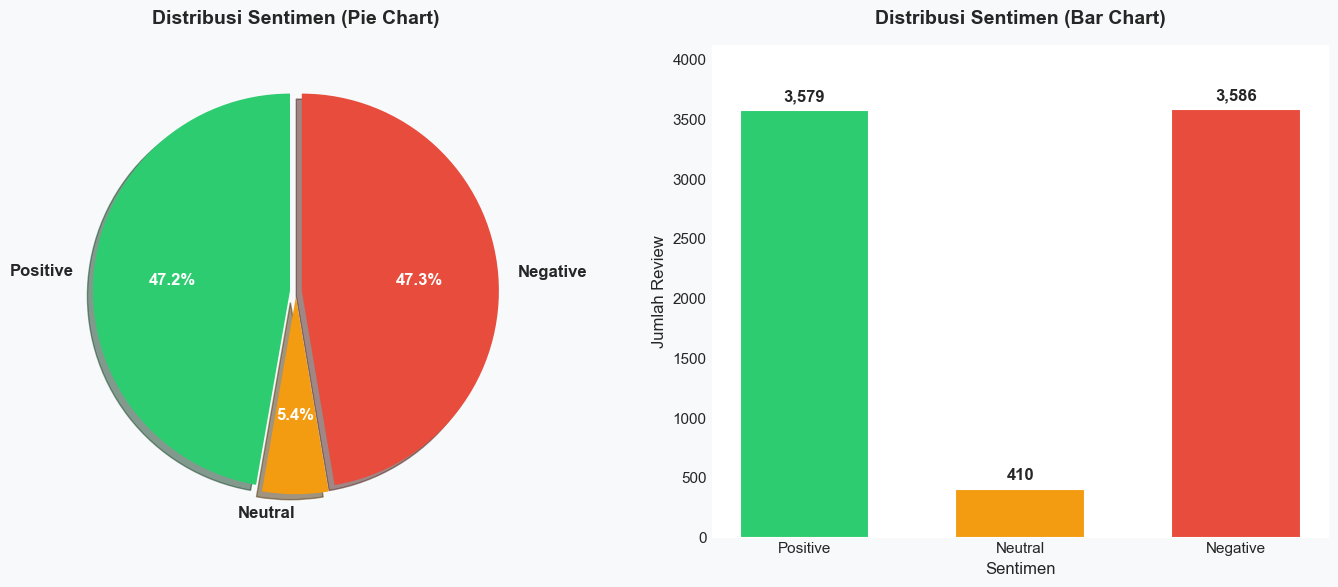

💾 Grafik disimpan ke: static/images/sentiment_distribution.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════
# 4.1 Distribusi Sentimen — Pie Chart & Bar Chart
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Pie Chart ──
sentiment_counts = df['sentiment'].value_counts()
order = ['Positive', 'Neutral', 'Negative']
sentiment_ordered = sentiment_counts.reindex(order)
colors = [COLORS[s] for s in order]

wedges, texts, autotexts = axes[0].pie(
    sentiment_ordered.values,
    labels=sentiment_ordered.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.03, 0.03, 0.03),
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[0].set_title('Distribusi Sentimen (Pie Chart)', fontsize=14, fontweight='bold', pad=15)

# ── Bar Chart ──
bars = axes[1].bar(sentiment_ordered.index, sentiment_ordered.values, color=colors,
                    edgecolor='white', linewidth=1.5, width=0.6)

# Tambahkan label di atas bar
for bar, val in zip(bars, sentiment_ordered.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

axes[1].set_title('Distribusi Sentimen (Bar Chart)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Sentimen', fontsize=12)
axes[1].set_ylabel('Jumlah Review', fontsize=12)
axes[1].set_ylim(0, sentiment_ordered.max() * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'sentiment_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Grafik disimpan ke: static/images/sentiment_distribution.png')

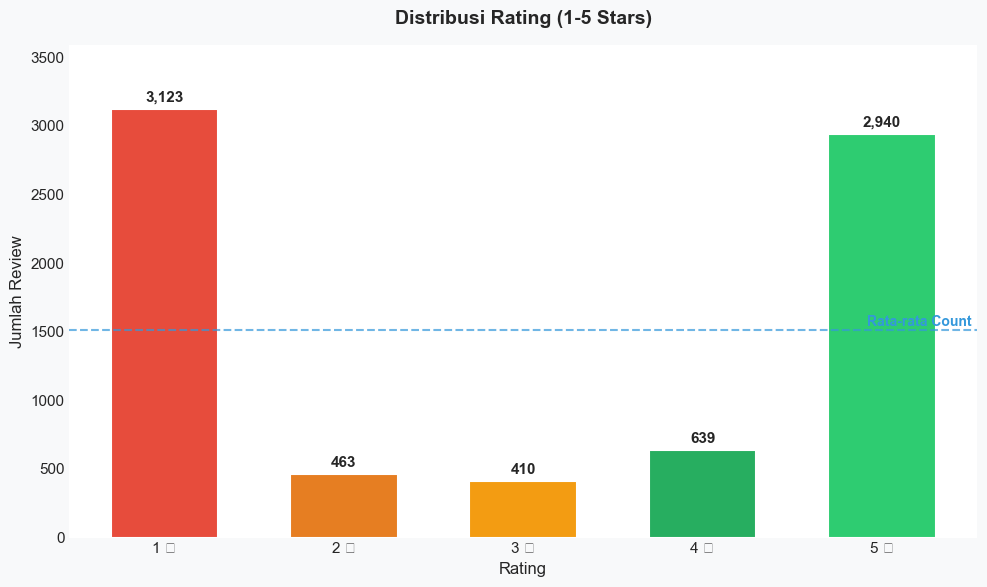

⭐ Rata-rata Rating: 2.97


In [13]:
# ══════════════════════════════════════════════════════════════════════════
# 4.2 Distribusi Rating — Bar Chart
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

rating_counts = df['rating'].value_counts().sort_index()
bars = ax.bar(rating_counts.index.astype(str) + ' ⭐', rating_counts.values,
              color=COLORS['rating'], edgecolor='white', linewidth=1.5, width=0.6)

# Label di atas bar
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Distribusi Rating (1-5 Stars)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Jumlah Review', fontsize=12)
ax.set_ylim(0, rating_counts.max() * 1.15)

# Tambahkan rata-rata
avg_rating = df['rating'].mean()
ax.axhline(y=rating_counts.mean(), color='#3498db', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(4.5, rating_counts.mean() + 30, f'Rata-rata Count', color='#3498db',
        fontsize=10, fontweight='bold', ha='right')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'rating_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'⭐ Rata-rata Rating: {avg_rating:.2f}')

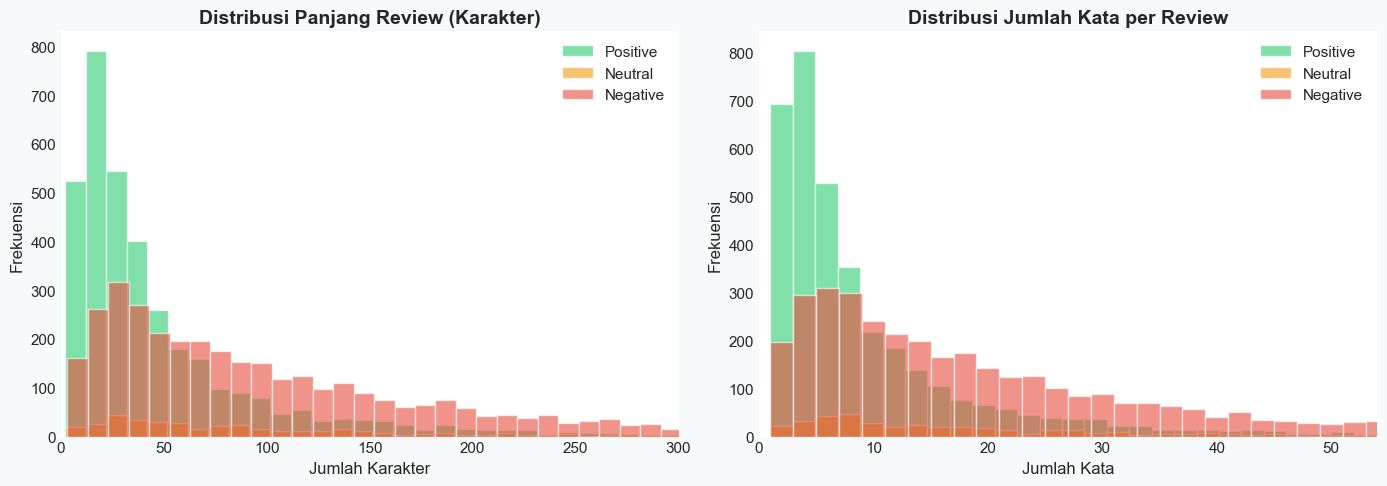

📏 Statistik Panjang Review:
          review_length                                               \
                  count   mean    std  min   25%   50%    75%    max   
sentiment                                                              
Negative         3586.0  118.5  109.7  3.0  38.0  83.0  159.0  500.0   
Neutral           410.0  107.8  101.9  2.0  36.2  74.5  141.5  499.0   
Positive         3579.0   53.0   67.4  2.0  16.0  30.0   60.0  500.0   

          word_count                                           
               count  mean   std  min  25%   50%   75%    max  
sentiment                                                      
Negative      3586.0  21.5  19.9  1.0  7.0  15.0  29.0  101.0  
Neutral        410.0  19.9  18.7  1.0  7.0  13.0  27.0   99.0  
Positive      3579.0   9.7  11.8  1.0  3.0   6.0  11.0   99.0  


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# 4.3 Distribusi Panjang Review
# ══════════════════════════════════════════════════════════════════════════

df['review_length'] = df['review'].astype(str).apply(len)
df['word_count'] = df['review'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Distribusi karakter ──
for sentiment, color in COLORS.items():
    if sentiment in ['Positive', 'Neutral', 'Negative']:
        subset = df[df['sentiment'] == sentiment]['review_length']
        axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=sentiment, edgecolor='white')

axes[0].set_title('Distribusi Panjang Review (Karakter)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].set_xlim(0, df['review_length'].quantile(0.95))  # trim outliers

# ── Distribusi kata ──
for sentiment, color in COLORS.items():
    if sentiment in ['Positive', 'Neutral', 'Negative']:
        subset = df[df['sentiment'] == sentiment]['word_count']
        axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=sentiment, edgecolor='white')

axes[1].set_title('Distribusi Jumlah Kata per Review', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()
axes[1].set_xlim(0, df['word_count'].quantile(0.95))

plt.tight_layout()
plt.show()

# Statistik
print('📏 Statistik Panjang Review:')
print(df.groupby('sentiment')[['review_length', 'word_count']].describe().round(1))

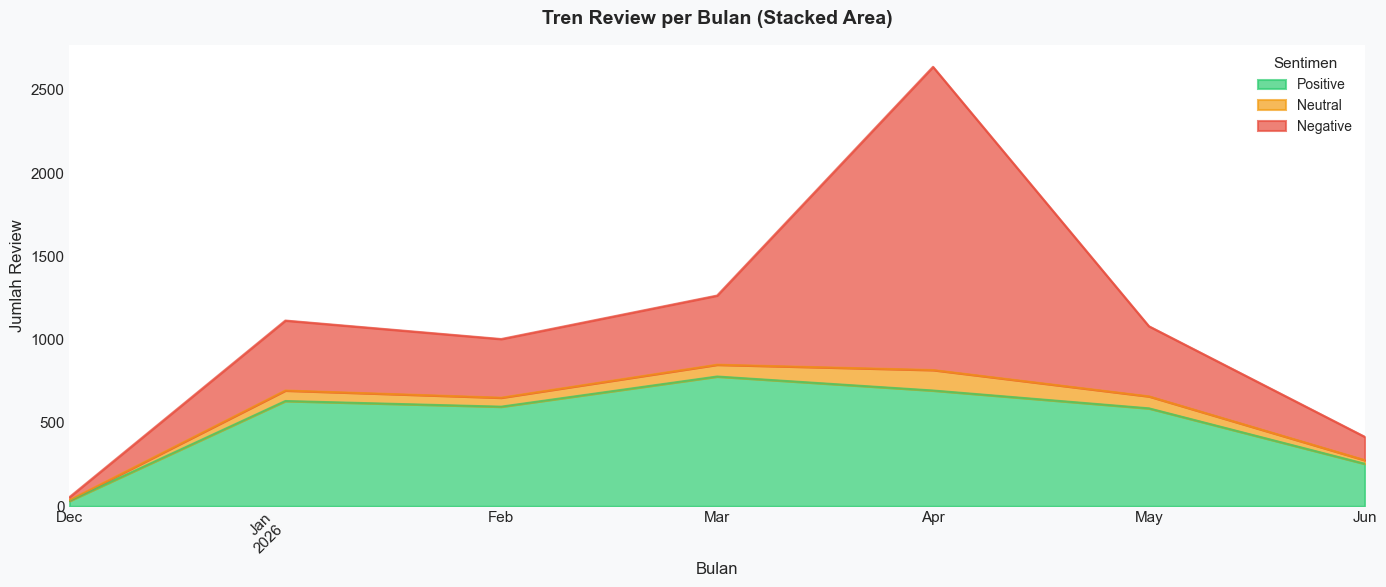

In [15]:
# ══════════════════════════════════════════════════════════════════════════
# 4.4 Tren Review per Bulan
# ══════════════════════════════════════════════════════════════════════════

df['month'] = df['date'].dt.to_period('M')
monthly = df.groupby(['month', 'sentiment']).size().unstack(fill_value=0)

# Pastikan urutan kolom benar
for col in ['Positive', 'Neutral', 'Negative']:
    if col not in monthly.columns:
        monthly[col] = 0
monthly = monthly[['Positive', 'Neutral', 'Negative']]

fig, ax = plt.subplots(figsize=(14, 6))

monthly.plot(kind='area', stacked=True, ax=ax,
             color=COLORS['palette'], alpha=0.7, linewidth=1.5)

ax.set_title('Tren Review per Bulan (Stacked Area)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bulan', fontsize=12)
ax.set_ylabel('Jumlah Review', fontsize=12)
ax.legend(title='Sentimen', fontsize=10)

# Rotasi x labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

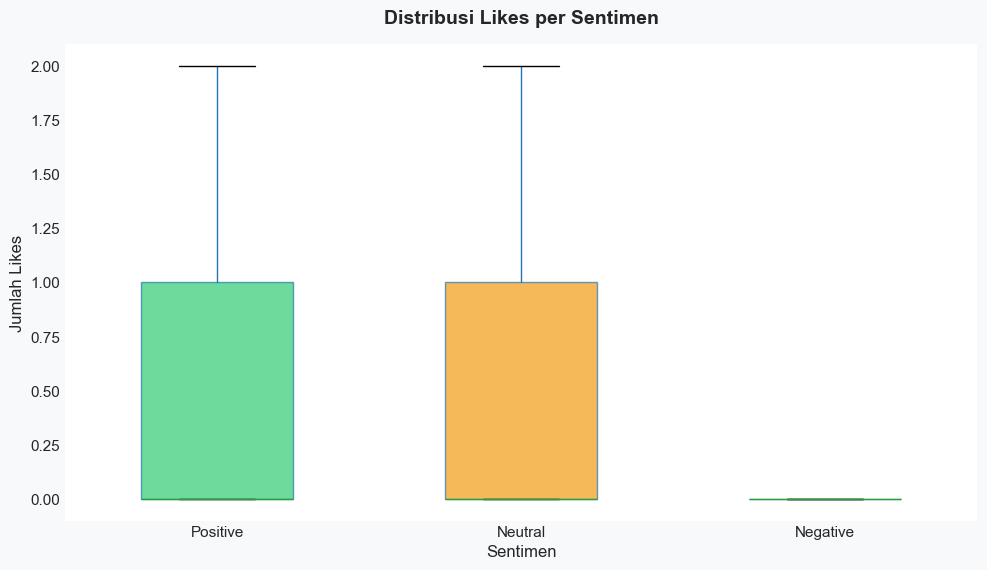

👍 Statistik Likes per Sentimen:
            count  mean   std  min  25%  50%  75%    max
sentiment                                               
Negative   3586.0   1.8  18.1  0.0  0.0  0.0  1.0  808.0
Neutral     410.0   1.4   8.9  0.0  0.0  0.0  1.0  171.0
Positive   3579.0   1.0  10.6  0.0  0.0  0.0  0.0  408.0


In [16]:
# ══════════════════════════════════════════════════════════════════════════
# 4.5 Rating vs Likes — Box Plot
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

sentiment_order = ['Positive', 'Neutral', 'Negative']
bp = df.boxplot(column='likes', by='sentiment', ax=ax,
                positions=[0, 1, 2], widths=0.5,
                patch_artist=True, showfliers=False,
                return_type='dict')

# Warna box
for patch, color in zip(bp['likes']['boxes'], COLORS['palette']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Distribusi Likes per Sentimen', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Sentimen', fontsize=12)
ax.set_ylabel('Jumlah Likes', fontsize=12)
ax.set_xticklabels(sentiment_order)
plt.suptitle('')  # Remove auto-title from boxplot

plt.tight_layout()
plt.show()

print('👍 Statistik Likes per Sentimen:')
print(df.groupby('sentiment')['likes'].describe().round(1))

---

## 🧹 5. NLP Preprocessing

Pipeline preprocessing teks:

1. **Lowercase** — konversi ke huruf kecil
2. **Remove URL** — hapus link/URL
3. **Remove Punctuation** — hapus tanda baca
4. **Remove Special Characters** — hapus karakter khusus
5. **Remove Numbers** — hapus angka
6. **Tokenization** — pecah teks menjadi token/kata
7. **Stopword Removal** — hapus kata-kata umum (the, is, at, dll)
8. **Lemmatization** — konversi kata ke bentuk dasar (running → run)

In [17]:
# ── Inisialisasi NLP Tools ────────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print(f'📚 Jumlah stopwords: {len(stop_words)}')
print(f'   Contoh stopwords: {list(stop_words)[:15]}')

📚 Jumlah stopwords: 198
   Contoh stopwords: ['t', 'her', 'each', 'your', 'won', "she'll", 'there', 'it', 'what', 'yourselves', 'theirs', 'myself', 'll', "i'd", 'm']


In [ ]:
# ── Fungsi Preprocessing ──────────────────────────────────────────────────
def clean_text(text):
    """
    Fungsi untuk membersihkan dan memproses teks review.
    
    Pipeline:
        1. Lowercase
        2. Remove URLs
        3. Remove punctuation
        4. Remove special characters
        5. Remove numbers
        6. Tokenization
        7. Stopword removal
        8. Lemmatization
    
    Args:
        text (str): Teks review mentah
    
    Returns:
        str: Teks yang sudah dibersihkan
    """
    # 1. Lowercase
    text = str(text).lower()
    
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # 3. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 4. Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 5. Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # 6. Tokenization
    tokens = word_tokenize(text)
    
    # 7. Stopword removal
    tokens = [t for t in tokens if t not in stop_words]
    
    # 8. Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    # Filter token pendek (< 2 karakter)
    tokens = [t for t in tokens if len(t) > 1]
    
    return ' '.join(tokens)


# ── Demo Preprocessing ────────────────────────────────────────────────────
demo_texts = [
    "This app is AMAZING!!! I love the video calling features. 👍👍👍",
    "Terrible experience... keeps CRASHING during meetings. Fix this ASAP! https://support.microsoft.com",
    "It's okay, nothing special. Some features are good but the UI could be better.",
]

print('🔧 Demo Preprocessing:')
print('=' * 70)
for i, text in enumerate(demo_texts, 1):
    cleaned = clean_text(text)
    print(f'\n  [{i}] Original : {text}')
    print(f'      Cleaned  : {cleaned}')
print('\n' + '=' * 70)

🔧 Demo Preprocessing:

  [1] Original : This app is AMAZING!!! I love the video calling features. 👍👍👍
      Cleaned  : app amazing love video calling feature

  [2] Original : Terrible experience... keeps CRASHING during meetings. Fix this ASAP! https://support.microsoft.com
      Cleaned  : terrible experience keep crashing meeting fix asap

  [3] Original : It's okay, nothing special. Some features are good but the UI could be better.
      Cleaned  : okay nothing special feature good ui could better



In [19]:
# ── Terapkan Preprocessing ke Seluruh Dataset ─────────────────────────────
if 'clean_review' not in df.columns:
    print('🔧 Memproses seluruh review...')
    start_time = time.time()
    
    df['clean_review'] = df['review'].apply(clean_text)
    
    elapsed = time.time() - start_time
    print(f'✅ Preprocessing selesai! ({elapsed:.1f} detik)')
    
    # Hapus review yang kosong setelah cleaning
    before = len(df)
    df = df[df['clean_review'].str.strip().str.len() > 0].copy()
    df = df.reset_index(drop=True)
    removed = before - len(df)
    
    print(f'   Dihapus (kosong): {removed:,}')
    print(f'   Sisa review     : {len(df):,}')
    
    # Simpan
    df.to_csv(CSV_PATH, index=False)
    print(f'💾 Data disimpan ke: {CSV_PATH}')
else:
    print('✅ Kolom clean_review sudah ada.')
    # Pastikan tidak ada NaN
    df = df.dropna(subset=['clean_review']).copy()
    df = df[df['clean_review'].str.strip().str.len() > 0].copy()
    df = df.reset_index(drop=True)
    print(f'   Total review: {len(df):,}')

✅ Kolom clean_review sudah ada.
   Total review: 7,575


In [20]:
# ── Perbandingan Sebelum dan Sesudah Preprocessing ────────────────────────
print('📝 Contoh Review Sebelum vs Sesudah Preprocessing:')
print('=' * 80)

for i in range(5):
    print(f'\n  [{i+1}] Rating    : {"⭐" * df.iloc[i]["rating"]}')
    print(f'      Sentiment : {df.iloc[i]["sentiment"]}')
    print(f'      Original  : {df.iloc[i]["review"][:100]}...')
    print(f'      Cleaned   : {df.iloc[i]["clean_review"][:100]}...')

print('\n' + '=' * 80)

📝 Contoh Review Sebelum vs Sesudah Preprocessing:

  [1] Rating    : ⭐
      Sentiment : Negative
      Original  : link not working in my profile and this app sucks....
      Cleaned   : link working profile app suck...

  [2] Rating    : ⭐
      Sentiment : Negative
      Original  : I give 1 star due to log in problem, I didn't access my account using email account....
      Cleaned   : give star due log problem didnt access account using email account...

  [3] Rating    : ⭐
      Sentiment : Negative
      Original  : I find it hard to believe that Microsoft can't block chat requests from people who are not in my Con...
      Cleaned   : find hard believe microsoft cant block chat request people contact seems way stop annoyance hide pro...

  [4] Rating    : ⭐
      Sentiment : Negative
      Original  : I reinstalled the app. I cleared cache and checked permissions. My employer wants me to use it. Been...
      Cleaned   : reinstalled app cleared cache checked permission employer

In [1]:
# 1. Install library (jika belum)
# !pip install pyspellchecker

from spellchecker import SpellChecker

# 2. Inisialisasi SpellChecker & load kata-kata umum agar tidak salah koreksi
spell = SpellChecker()
spell.word_frequency.load_words([
    "app", "apps", "teams", "microsoft", "chat", "meeting", "meetings", 
    "android", "ios", "zoom", "skype", "wifi", "internet", "notification", "notifications"
])

# 3. Custom kamus slang/typo ekstrem
CUSTOM_WORDS = {
    "thiz": "this",
    "iz": "is",
    "zuckk": "suck",
    "zuck": "suck",
    "zuckin": "sucking",
    "zucks": "sucks",
    "suckk": "suck",
    "sux": "suck",
}

# 4. Tambahkan logika ini ke dalam fungsi pembersihan (clean_text) setelah Tokenization:
# (Ganti bagian tokenization di fungsi pembersihan Anda dengan kode ini)
"""
tokens = word_tokenize(text)

# spelling & slang correction
corrected_tokens = []
for t in tokens:
    if t in CUSTOM_WORDS:
        corrected_tokens.append(CUSTOM_WORDS[t])
    elif t in spell:
        corrected_tokens.append(t)
    else:
        corrected = spell.correction(t)
        corrected_tokens.append(corrected if corrected else t)
tokens = corrected_tokens
"""


'\ntokens = word_tokenize(text)\n\n# spelling & slang correction\ncorrected_tokens = []\nfor t in tokens:\n    if t in CUSTOM_WORDS:\n        corrected_tokens.append(CUSTOM_WORDS[t])\n    elif t in spell:\n        corrected_tokens.append(t)\n    else:\n        corrected = spell.correction(t)\n        corrected_tokens.append(corrected if corrected else t)\ntokens = corrected_tokens\n'

---

## 🔤 6. Feature Extraction — TF-IDF Vectorization

Mengkonversi teks menjadi representasi numerik menggunakan **TF-IDF (Term Frequency — Inverse Document Frequency)**.

**Parameter:**
- `max_features = 5000` — Jumlah fitur maksimal
- `ngram_range = (1, 2)` — Unigram dan bigram

In [21]:
# ── TF-IDF Vectorization ──────────────────────────────────────────────────
MAX_FEATURES = 5000
NGRAM_RANGE = (1, 2)

tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    stop_words='english',
)

X = tfidf_vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

print(f'🔤 TF-IDF Feature Extraction')
print(f'   max_features : {MAX_FEATURES}')
print(f'   ngram_range  : {NGRAM_RANGE}')
print(f'   Feature matrix shape: {X.shape}')
print(f'   Vocabulary size     : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'\n   Contoh fitur: {list(tfidf_vectorizer.get_feature_names_out()[:20])}')

🔤 TF-IDF Feature Extraction
   max_features : 5000
   ngram_range  : (1, 2)
   Feature matrix shape: (7575, 5000)
   Vocabulary size     : 5,000

   Contoh fitur: ['aadsts', 'aadsts error', 'aap', 'abandoned', 'abd', 'ability', 'ability work', 'able', 'able access', 'able connect', 'able delete', 'able join', 'able load', 'able log', 'able login', 'able open', 'able receive', 'able send', 'able sign', 'able use']


In [22]:
# ── Top TF-IDF Features ───────────────────────────────────────────────────
# Fitur TF-IDF dengan skor rata-rata tertinggi

feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_means = X.mean(axis=0).A1  # rata-rata TF-IDF per fitur
top_indices = tfidf_means.argsort()[-20:][::-1]

print('🏆 Top 20 TF-IDF Features (rata-rata skor tertinggi):')
print('=' * 40)
for rank, idx in enumerate(top_indices, 1):
    print(f'   {rank:2d}. {feature_names[idx]:20s} : {tfidf_means[idx]:.6f}')

🏆 Top 20 TF-IDF Features (rata-rata skor tertinggi):
    1. app                  : 0.045592
    2. good                 : 0.041668
    3. work                 : 0.030105
    4. team                 : 0.019991
    5. great                : 0.019788
    6. use                  : 0.019394
    7. working              : 0.016795
    8. meeting              : 0.015402
    9. update               : 0.014526
   10. nice                 : 0.013218
   11. message              : 0.013046
   12. easy                 : 0.012465
   13. like                 : 0.011925
   14. time                 : 0.011445
   15. best                 : 0.011155
   16. doesnt               : 0.011066
   17. phone                : 0.010385
   18. good app             : 0.009149
   19. issue                : 0.009096
   20. login                : 0.008979


---

## ✂️ 7. Train-Test Split

Membagi data menjadi **80% Training** dan **20% Testing** dengan stratifikasi.

In [23]:
# ── Split Data ────────────────────────────────────────────────────────────
TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y  # menjaga proporsi sentimen
)

print(f'✂️ Data Split:')
print(f'   Test size    : {TEST_SIZE}')
print(f'   Random state : {RANDOM_STATE}')
print(f'   Stratified   : Yes')
print(f'\n   Training set : {X_train.shape[0]:,} samples')
print(f'   Testing set  : {X_test.shape[0]:,} samples')

# Verifikasi stratifikasi
print(f'\n📊 Distribusi Sentimen di Training Set:')
for s, c in y_train.value_counts().items():
    print(f'   {s:10s}: {c:,} ({c/len(y_train)*100:.1f}%)')

print(f'\n📊 Distribusi Sentimen di Testing Set:')
for s, c in y_test.value_counts().items():
    print(f'   {s:10s}: {c:,} ({c/len(y_test)*100:.1f}%)')

✂️ Data Split:
   Test size    : 0.2
   Random state : 42
   Stratified   : Yes

   Training set : 6,060 samples
   Testing set  : 1,515 samples

📊 Distribusi Sentimen di Training Set:
   Negative  : 2,869 (47.3%)
   Positive  : 2,863 (47.2%)
   Neutral   : 328 (5.4%)

📊 Distribusi Sentimen di Testing Set:
   Negative  : 717 (47.3%)
   Positive  : 716 (47.3%)
   Neutral   : 82 (5.4%)


---

## 🤖 8. Model Training

Melatih dan membandingkan **3 model** Machine Learning:

| # | Model | Deskripsi |
|:-:|-------|----------|
| 1 | **Logistic Regression** | Model linear klasik, cepat dan efektif untuk teks |
| 2 | **Multinomial Naive Bayes** | Model probabilistik, sangat cocok untuk klasifikasi teks |
| 3 | **Random Forest** | Ensemble model berbasis decision tree |

In [25]:
# ── Definisi Model ────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        C=1.0,
        solver='lbfgs',
    ),
    'Multinomial Naive Bayes': MultinomialNB(
        alpha=1.0,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_depth=None,
    ),
}

print(f'🤖 Model yang akan dilatih: {len(models)}')
for i, (name, model) in enumerate(models.items(), 1):
    print(f'   {i}. {name}')

🤖 Model yang akan dilatih: 3
   1. Logistic Regression
   2. Multinomial Naive Bayes
   3. Random Forest


In [26]:
# ── Training & Evaluasi Semua Model ───────────────────────────────────────
results = {}
class_labels = sorted(y.unique())  # ['Negative', 'Neutral', 'Positive']

print('🏋️ Training Models...')
print('=' * 70)

for name, model in models.items():
    print(f'\n  📌 Training: {name}')
    start_time = time.time()
    
    # 1. Train model
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # 2. Predict
    y_pred = model.predict(X_test)
    
    # 3. Probabilities (jika tersedia)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
    else:
        y_proba = None
    
    # 4. Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    report = classification_report(y_test, y_pred, labels=class_labels, zero_division=0)
    
    # Cross-validation (5-fold)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    
    results[name] = {
        'model': model,
        'accuracy': round(acc, 4),
        'precision': round(prec, 4),
        'recall': round(rec, 4),
        'f1_score': round(f1, 4),
        'confusion_matrix': cm,
        'classification_report': report,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'cv_scores': cv_scores,
        'train_time': train_time,
    }
    
    print(f'     Accuracy  : {acc:.4f}')
    print(f'     Precision : {prec:.4f}')
    print(f'     Recall    : {rec:.4f}')
    print(f'     F1 Score  : {f1:.4f}')
    print(f'     CV F1     : {cv_scores.mean():.4f} (±{cv_scores.std():.4f})')
    print(f'     Time      : {train_time:.2f}s')

print('\n' + '=' * 70)
print('✅ Semua model berhasil dilatih!')

🏋️ Training Models...

  📌 Training: Logistic Regression
     Accuracy  : 0.8548
     Precision : 0.8091
     Recall    : 0.8548
     F1 Score  : 0.8311
     CV F1     : 0.8286 (±0.0062)
     Time      : 0.22s

  📌 Training: Multinomial Naive Bayes
     Accuracy  : 0.8469
     Precision : 0.8036
     Recall    : 0.8469
     F1 Score  : 0.8235
     CV F1     : 0.8174 (±0.0127)
     Time      : 0.02s

  📌 Training: Random Forest
     Accuracy  : 0.8376
     Precision : 0.8113
     Recall    : 0.8376
     F1 Score  : 0.8158
     CV F1     : 0.8173 (±0.0045)
     Time      : 1.83s

✅ Semua model berhasil dilatih!


---

## 📈 9. Model Evaluation & Visualization

Evaluasi mendetail semua model dengan berbagai visualisasi.

In [27]:
# ══════════════════════════════════════════════════════════════════════════
# 9.1 Classification Report (detail per model)
# ══════════════════════════════════════════════════════════════════════════

for name, res in results.items():
    print(f'\n{"═" * 70}')
    print(f'📋 Classification Report — {name}')
    print(f'{"═" * 70}')
    print(res['classification_report'])


══════════════════════════════════════════════════════════════════════
📋 Classification Report — Logistic Regression
══════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Negative       0.84      0.91      0.87       717
     Neutral       0.00      0.00      0.00        82
    Positive       0.87      0.89      0.88       716

    accuracy                           0.85      1515
   macro avg       0.57      0.60      0.59      1515
weighted avg       0.81      0.85      0.83      1515


══════════════════════════════════════════════════════════════════════
📋 Classification Report — Multinomial Naive Bayes
══════════════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

    Negative       0.81      0.92      0.86       717
     Neutral       0.00      0.00      0.00        82
    Positive       0.89      0.87      0.88       716

    accuracy       

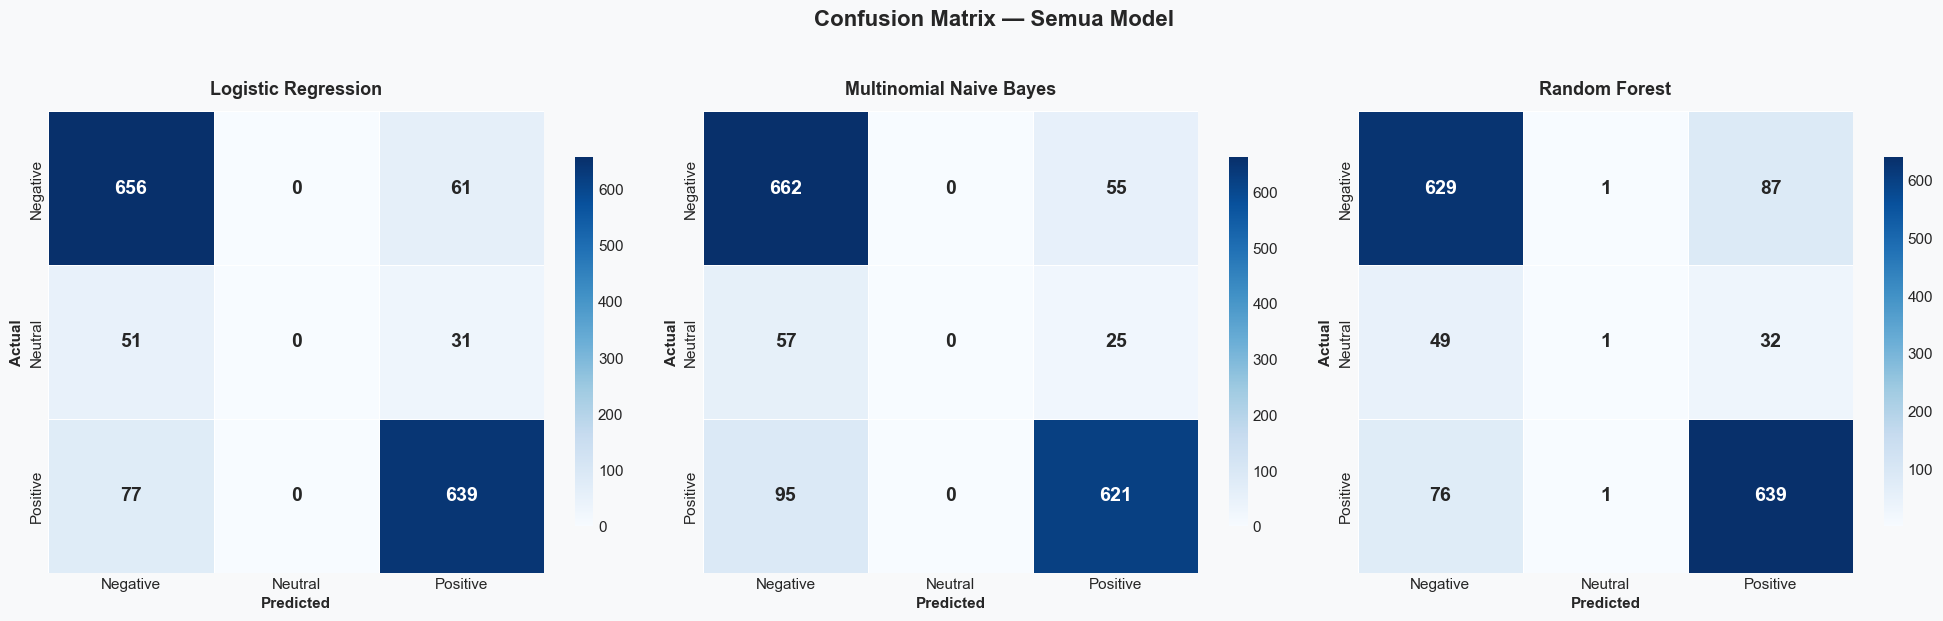

💾 Grafik disimpan ke: static/images/confusion_matrix_all.png


In [28]:
# ══════════════════════════════════════════════════════════════════════════
# 9.2 Confusion Matrix — Heatmap untuk Setiap Model
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    cm = res['confusion_matrix']
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=ax, linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.8},
        annot_kws={'size': 14, 'fontweight': 'bold'},
    )
    
    ax.set_title(f'{name}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix — Semua Model', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'confusion_matrix_all.png'), dpi=150, bbox_inches='tight')
plt.show()

print('💾 Grafik disimpan ke: static/images/confusion_matrix_all.png')

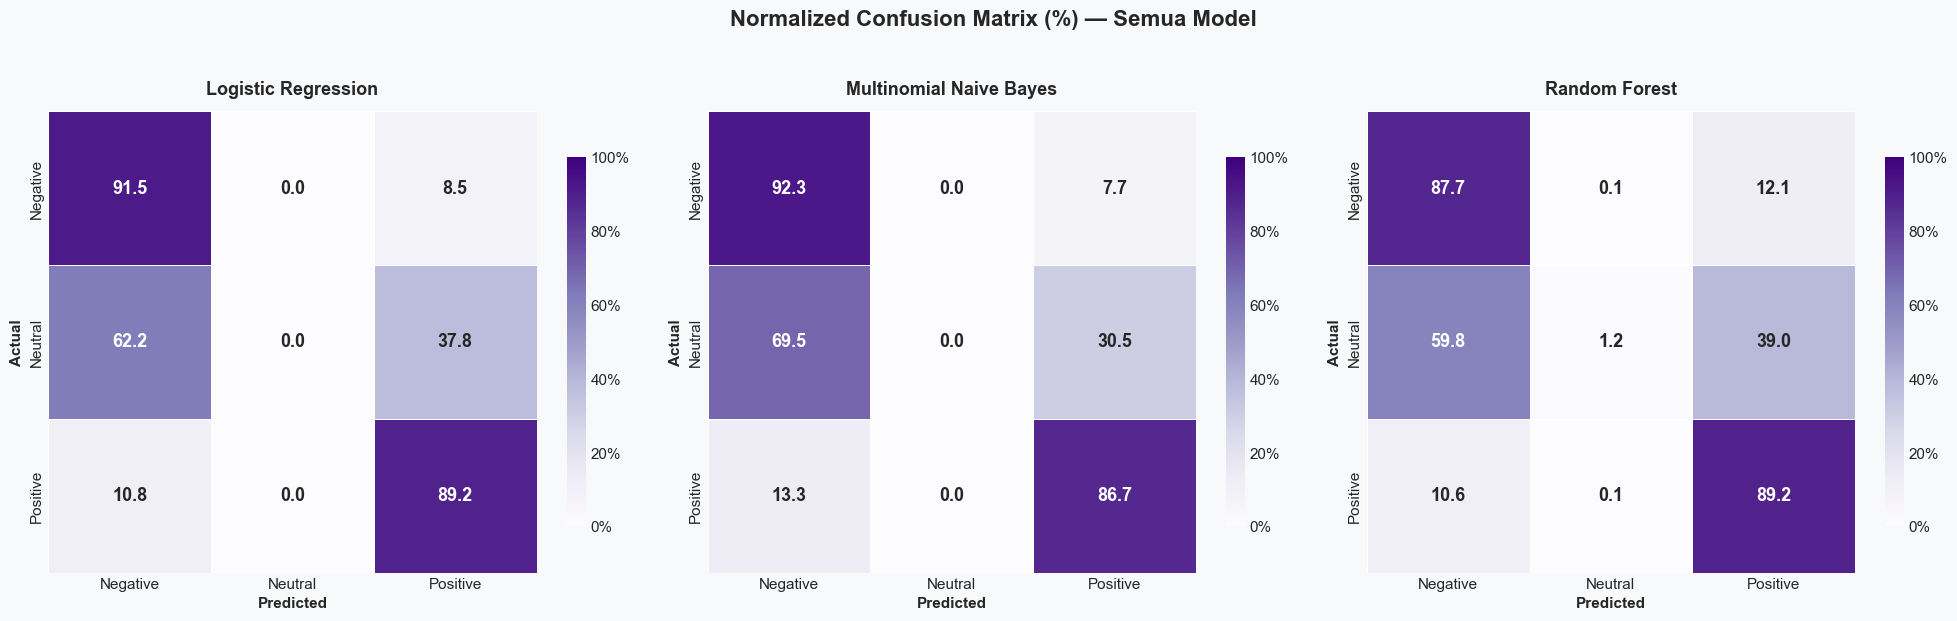

In [29]:
# ══════════════════════════════════════════════════════════════════════════
# 9.3 Normalized Confusion Matrix (Persentase)
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    cm = res['confusion_matrix']
    
    # Normalisasi per baris (true label)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1f', cmap='Purples',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=ax, linewidths=0.5, linecolor='white',
        cbar_kws={'shrink': 0.8, 'format': '%.0f%%'},
        annot_kws={'size': 13, 'fontweight': 'bold'},
        vmin=0, vmax=100,
    )
    
    ax.set_title(f'{name}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=11, fontweight='bold')

plt.suptitle('Normalized Confusion Matrix (%) — Semua Model', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

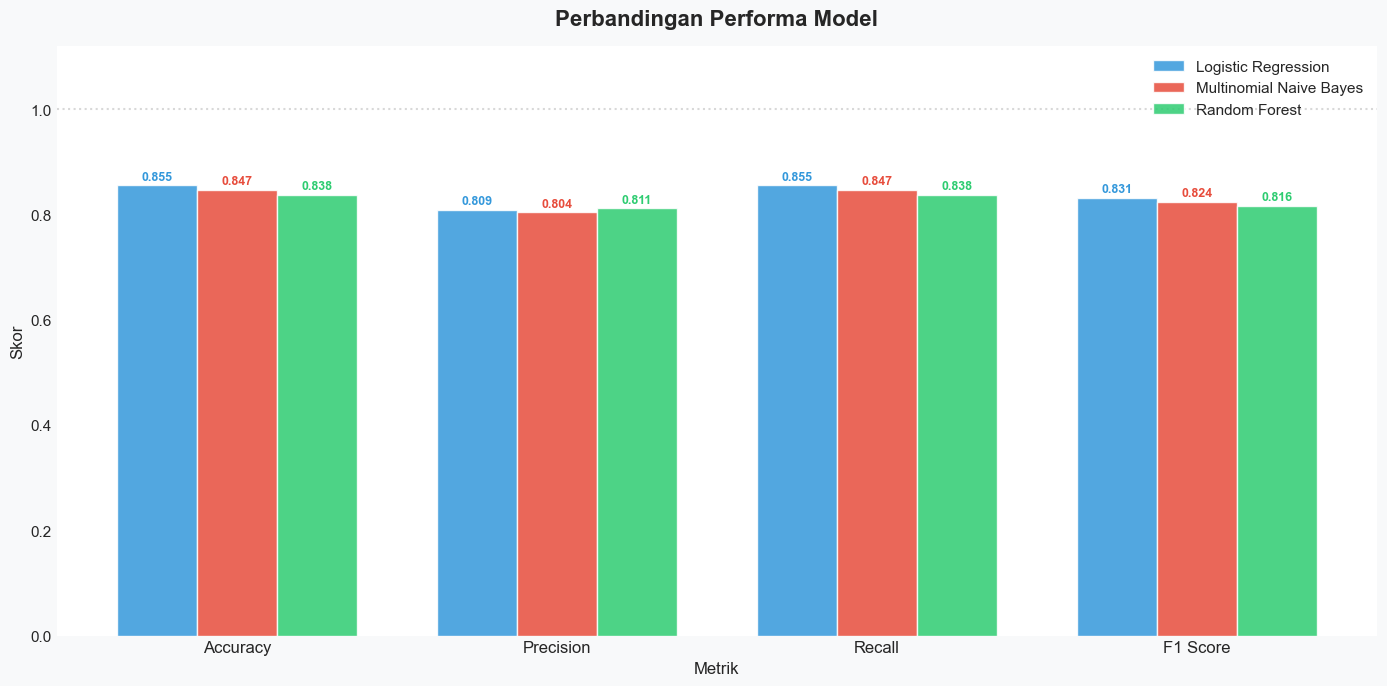


📊 Tabel Perbandingan Model:
                         Accuracy  Precision  Recall  F1 Score
Logistic Regression        0.8548     0.8091  0.8548    0.8311
Multinomial Naive Bayes    0.8469     0.8036  0.8469    0.8235
Random Forest              0.8376     0.8113  0.8376    0.8158


In [30]:
# ══════════════════════════════════════════════════════════════════════════
# 9.4 Model Comparison — Bar Chart
# ══════════════════════════════════════════════════════════════════════════

# Siapkan data perbandingan
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = list(results.keys())
model_colors = ['#3498db', '#e74c3c', '#2ecc71']

comparison_data = []
for name, res in results.items():
    comparison_data.append([
        res['accuracy'], res['precision'], res['recall'], res['f1_score']
    ])

comparison_df = pd.DataFrame(comparison_data, columns=metrics_names, index=model_names)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(metrics_names))
width = 0.25

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    bars = ax.bar(x + i * width, comparison_df.loc[name].values, width,
                  label=name, color=color, edgecolor='white', linewidth=1,
                  alpha=0.85)
    
    # Label di atas bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=color)

ax.set_title('Perbandingan Performa Model', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11, loc='upper right')
ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Tampilkan tabel
print('\n📊 Tabel Perbandingan Model:')
print(comparison_df.to_string())

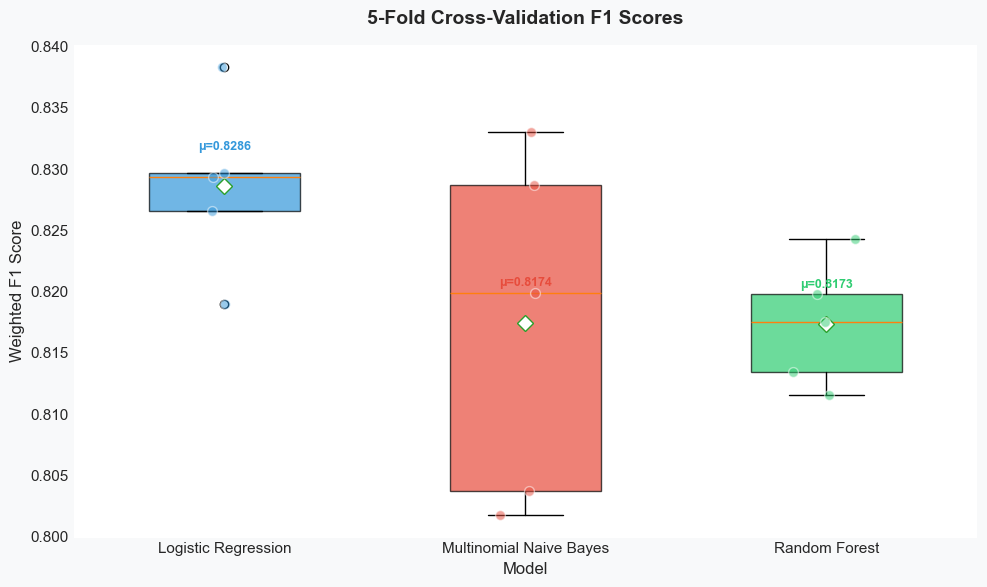

In [31]:
# ══════════════════════════════════════════════════════════════════════════
# 9.5 Cross-Validation Scores — Box Plot
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))

cv_data = [res['cv_scores'] for res in results.values()]

bp = ax.boxplot(cv_data, labels=model_names, patch_artist=True, widths=0.5,
                showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'white', 'markersize': 8})

for patch, color in zip(bp['boxes'], model_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Tambahkan skor individual
for i, (name, scores) in enumerate(zip(model_names, cv_data)):
    x_jitter = np.random.normal(i + 1, 0.04, size=len(scores))
    ax.scatter(x_jitter, scores, alpha=0.5, color=model_colors[i], s=50, zorder=3, edgecolors='white')

ax.set_title('5-Fold Cross-Validation F1 Scores', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Weighted F1 Score', fontsize=12)
ax.set_xlabel('Model', fontsize=12)

# Tambahkan mean annotation
for i, scores in enumerate(cv_data):
    ax.text(i + 1, scores.mean() + 0.003, f'μ={scores.mean():.4f}',
            ha='center', fontweight='bold', fontsize=9, color=model_colors[i])

plt.tight_layout()
plt.show()

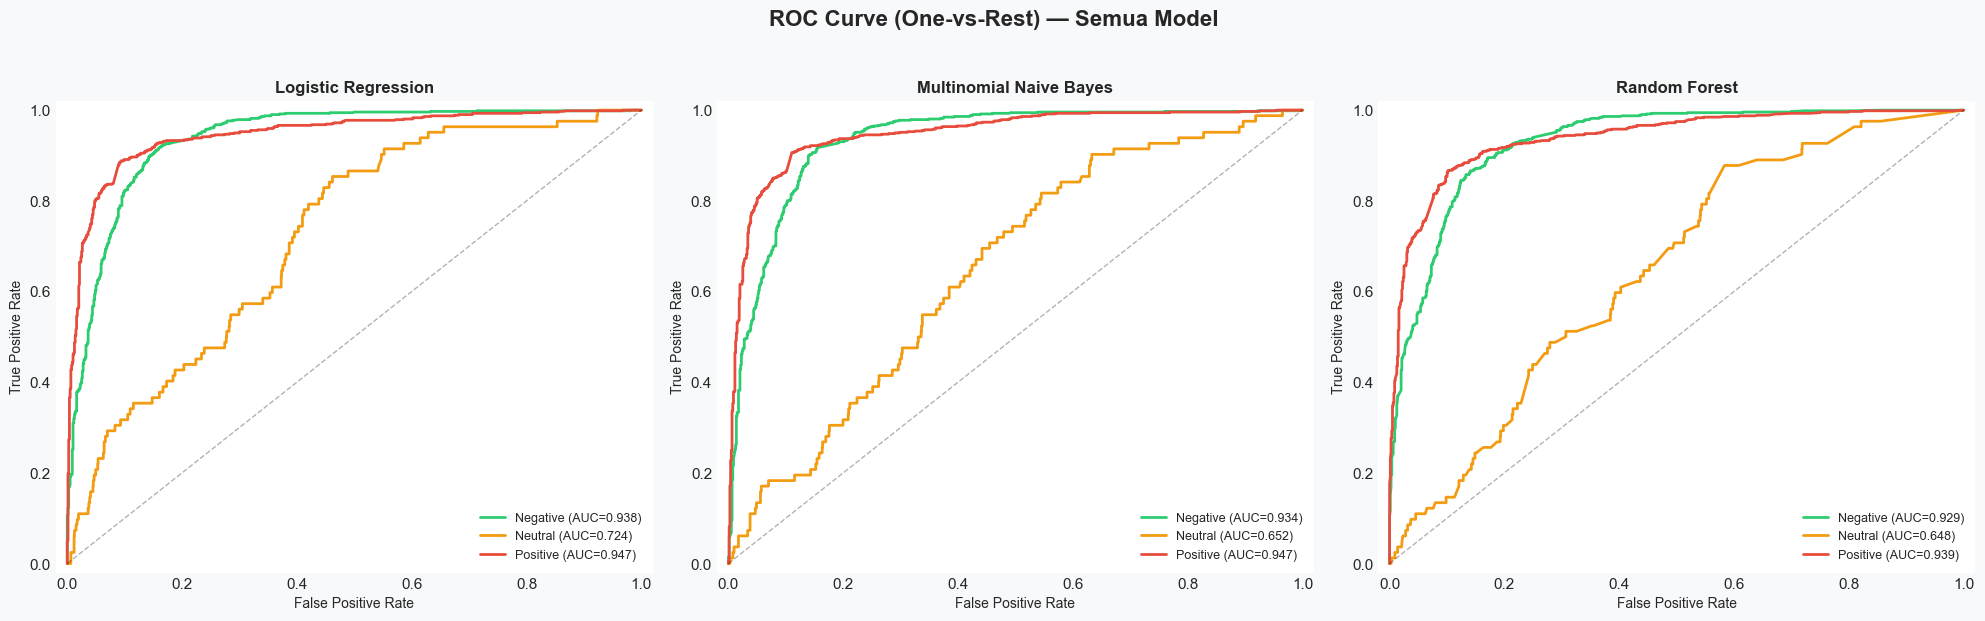

💾 Grafik disimpan ke: static/images/roc_curves.png


In [32]:
# ══════════════════════════════════════════════════════════════════════════
# 9.6 ROC Curve — One-vs-Rest (OvR) untuk Multiclass
# ══════════════════════════════════════════════════════════════════════════

# Binarize labels untuk ROC
y_test_bin = label_binarize(y_test, classes=class_labels)
n_classes = len(class_labels)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

roc_colors = ['#2ecc71', '#f39c12', '#e74c3c']  # per class

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    
    if res['y_proba'] is not None:
        y_proba = res['y_proba']
        
        # ROC per kelas
        for i, (class_name, color) in enumerate(zip(class_labels, roc_colors)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, linewidth=2,
                    label=f'{class_name} (AUC={roc_auc:.3f})')
        
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)
        ax.set_xlabel('False Positive Rate', fontsize=10)
        ax.set_ylabel('True Positive Rate', fontsize=10)
        ax.set_title(f'{name}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=9, loc='lower right')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
    else:
        ax.text(0.5, 0.5, 'No probability\navailable', ha='center', va='center',
                fontsize=12, color='gray')
        ax.set_title(f'{name}', fontsize=12, fontweight='bold')

plt.suptitle('ROC Curve (One-vs-Rest) — Semua Model', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print('💾 Grafik disimpan ke: static/images/roc_curves.png')

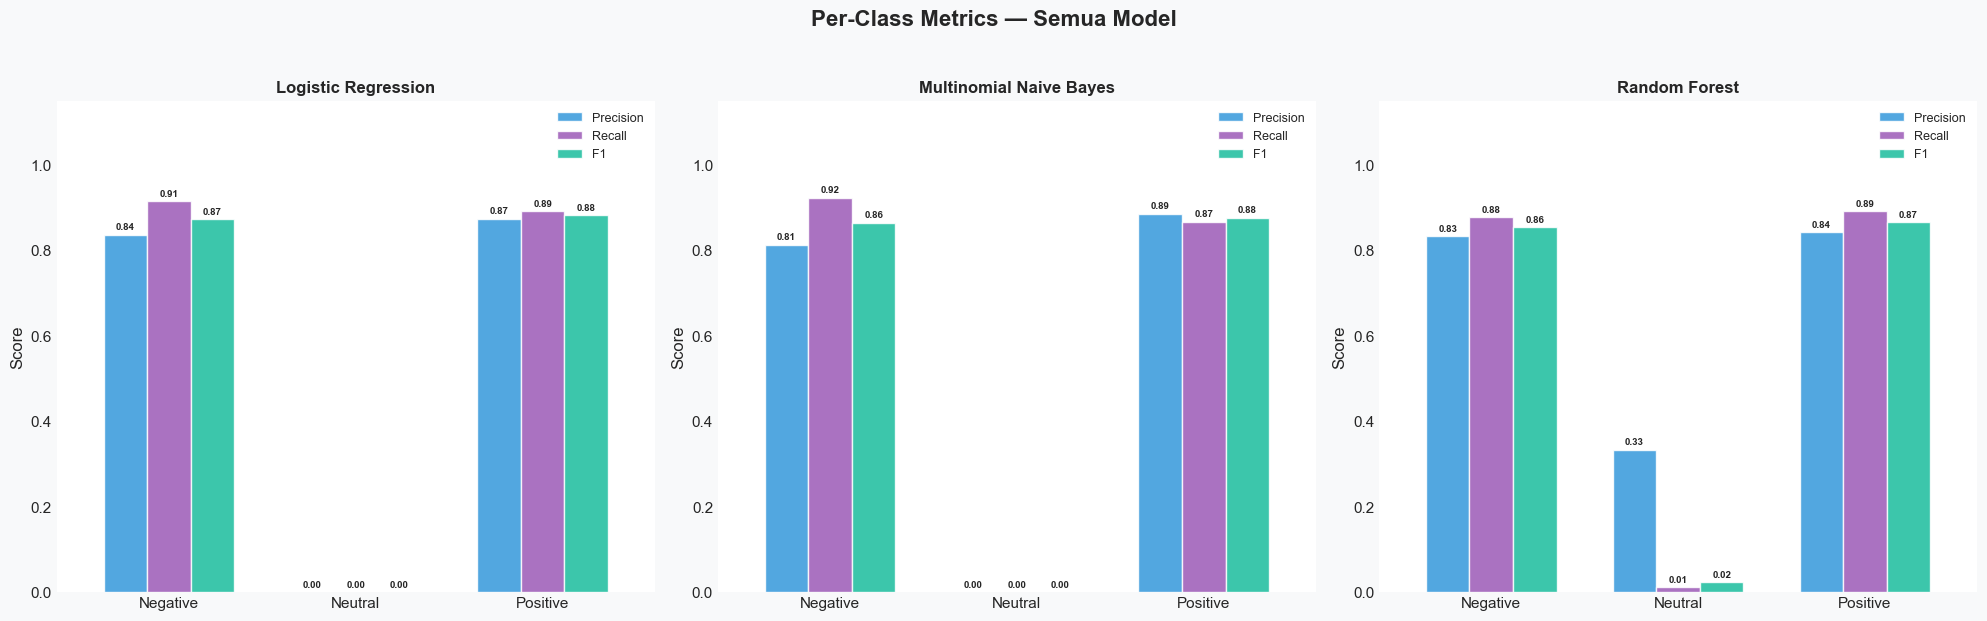

In [33]:
# ══════════════════════════════════════════════════════════════════════════
# 9.7 Per-Class Metrics — Grouped Bar Chart
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx]
    
    # Parse classification report per class
    report_dict = classification_report(y_test, res['y_pred'], 
                                        labels=class_labels, 
                                        output_dict=True, zero_division=0)
    
    per_class_metrics = []
    for cls in class_labels:
        per_class_metrics.append({
            'Class': cls,
            'Precision': report_dict[cls]['precision'],
            'Recall': report_dict[cls]['recall'],
            'F1': report_dict[cls]['f1-score'],
        })
    
    pc_df = pd.DataFrame(per_class_metrics).set_index('Class')
    
    pc_df.plot(kind='bar', ax=ax, color=['#3498db', '#9b59b6', '#1abc9c'],
               edgecolor='white', width=0.7, alpha=0.85)
    
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=9)
    
    # Label values
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=7, fontweight='bold', padding=2)

plt.suptitle('Per-Class Metrics — Semua Model', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

🏆 Model Terbaik: Logistic Regression
   F1 Score: 0.8311

📈 Menghitung Learning Curve untuk Logistic Regression...


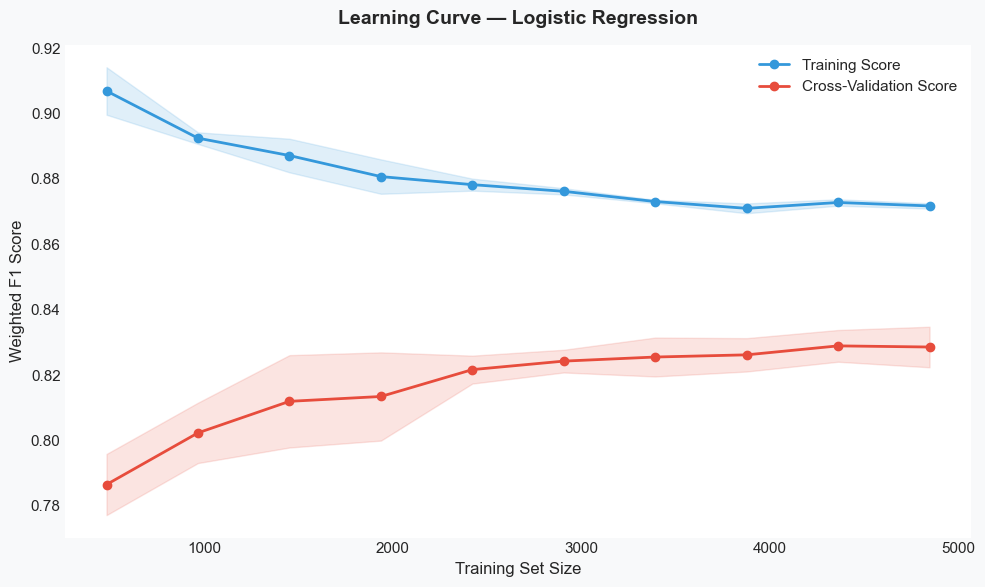

💾 Grafik disimpan ke: static/images/learning_curve.png


In [34]:
# ══════════════════════════════════════════════════════════════════════════
# 9.8 Learning Curve — Model Terbaik
# ══════════════════════════════════════════════════════════════════════════

# Tentukan model terbaik berdasarkan F1 Score
best_model_name = max(results, key=lambda k: results[k]['f1_score'])
best_result = results[best_model_name]

print(f'🏆 Model Terbaik: {best_model_name}')
print(f'   F1 Score: {best_result["f1_score"]:.4f}')

# Learning Curve
print(f'\n📈 Menghitung Learning Curve untuk {best_model_name}...')

train_sizes, train_scores, test_scores = learning_curve(
    best_result['model'], X_train, y_train,
    cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='#3498db')
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                alpha=0.15, color='#e74c3c')

ax.plot(train_sizes, train_mean, 'o-', color='#3498db', linewidth=2,
        markersize=6, label='Training Score')
ax.plot(train_sizes, test_mean, 'o-', color='#e74c3c', linewidth=2,
        markersize=6, label='Cross-Validation Score')

ax.set_title(f'Learning Curve — {best_model_name}', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Weighted F1 Score', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'learning_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print('💾 Grafik disimpan ke: static/images/learning_curve.png')

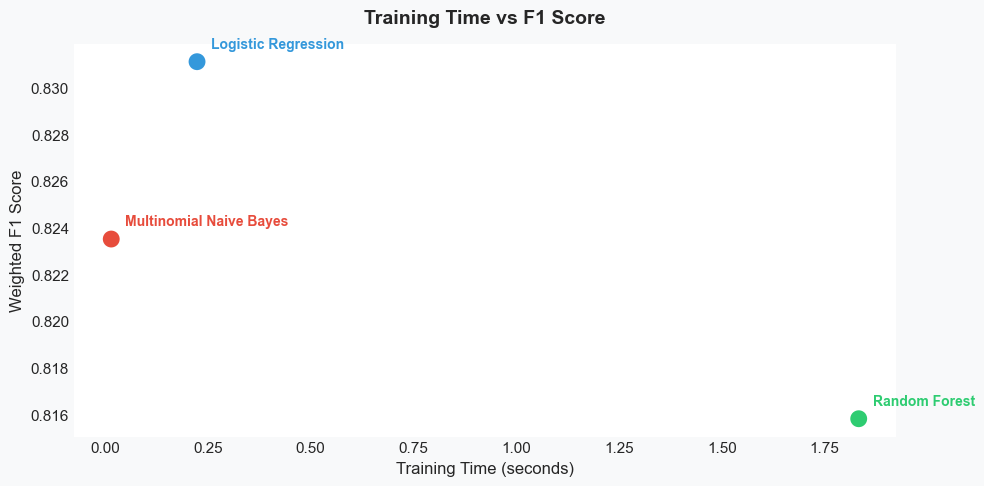

In [35]:
# ══════════════════════════════════════════════════════════════════════════
# 9.9 Training Time Comparison
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))

times = [res['train_time'] for res in results.values()]
f1_scores = [res['f1_score'] for res in results.values()]

# Scatter plot: waktu vs F1
scatter = ax.scatter(times, f1_scores, s=200, c=model_colors, 
                     edgecolors='white', linewidth=2, zorder=3)

for i, name in enumerate(model_names):
    ax.annotate(name, (times[i], f1_scores[i]),
                textcoords='offset points', xytext=(10, 10),
                fontsize=10, fontweight='bold', color=model_colors[i])

ax.set_title('Training Time vs F1 Score', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Training Time (seconds)', fontsize=12)
ax.set_ylabel('Weighted F1 Score', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

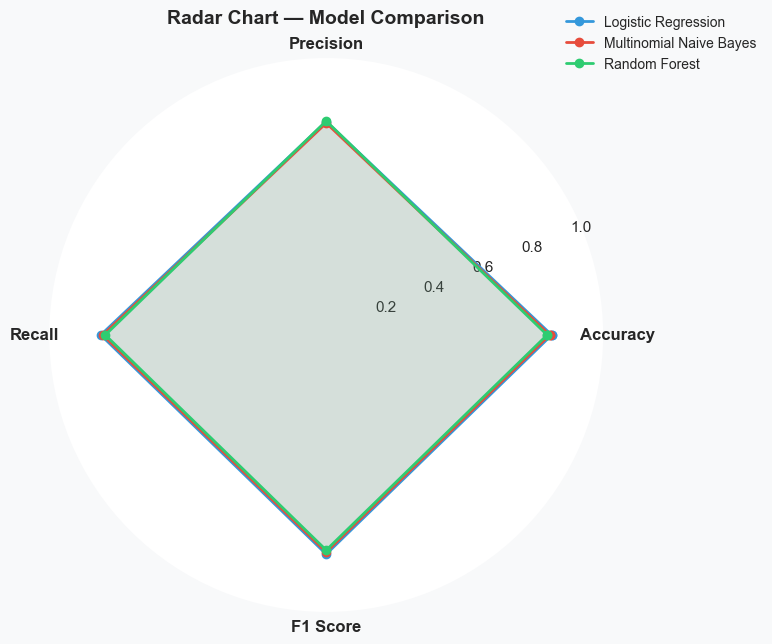

In [36]:
# ══════════════════════════════════════════════════════════════════════════
# 9.10 Radar Chart — Perbandingan Metrik Model
# ══════════════════════════════════════════════════════════════════════════

metrics_for_radar = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
num_metrics = len(metrics_for_radar)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (name, color) in enumerate(zip(model_names, model_colors)):
    values = comparison_df.loc[name].values.tolist()
    values += values[:1]  # close the polygon
    
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=name, markersize=6)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_for_radar, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_title('Radar Chart — Model Comparison', fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'radar_chart.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## 🏆 10. Pemilihan Model Terbaik

Model terbaik dipilih berdasarkan **Weighted F1 Score** tertinggi.

In [37]:
# ── Pilih Model Terbaik ───────────────────────────────────────────────────
best_model_name = max(results, key=lambda k: results[k]['f1_score'])
best_result = results[best_model_name]

print('🏆' + '=' * 60)
print(f'   MODEL TERBAIK: {best_model_name}')
print('=' * 63)
print(f'   Accuracy  : {best_result["accuracy"]:.4f} ({best_result["accuracy"]*100:.2f}%)')
print(f'   Precision : {best_result["precision"]:.4f} ({best_result["precision"]*100:.2f}%)')
print(f'   Recall    : {best_result["recall"]:.4f} ({best_result["recall"]*100:.2f}%)')
print(f'   F1 Score  : {best_result["f1_score"]:.4f} ({best_result["f1_score"]*100:.2f}%)')
print('=' * 63)

# Ranking semua model
print('\n📊 Ranking Model (berdasarkan F1 Score):')
ranked = sorted(results.items(), key=lambda x: x[1]['f1_score'], reverse=True)
for rank, (name, res) in enumerate(ranked, 1):
    marker = '👑' if rank == 1 else '  '
    print(f'   {marker} #{rank} {name:30s} F1={res["f1_score"]:.4f}')

🏆============================================================
   MODEL TERBAIK: Logistic Regression
   Accuracy  : 0.8548 (85.48%)
   Precision : 0.8091 (80.91%)
   Recall    : 0.8548 (85.48%)
   F1 Score  : 0.8311 (83.11%)

📊 Ranking Model (berdasarkan F1 Score):
   👑 #1 Logistic Regression            F1=0.8311
      #2 Multinomial Naive Bayes        F1=0.8235
      #3 Random Forest                  F1=0.8158


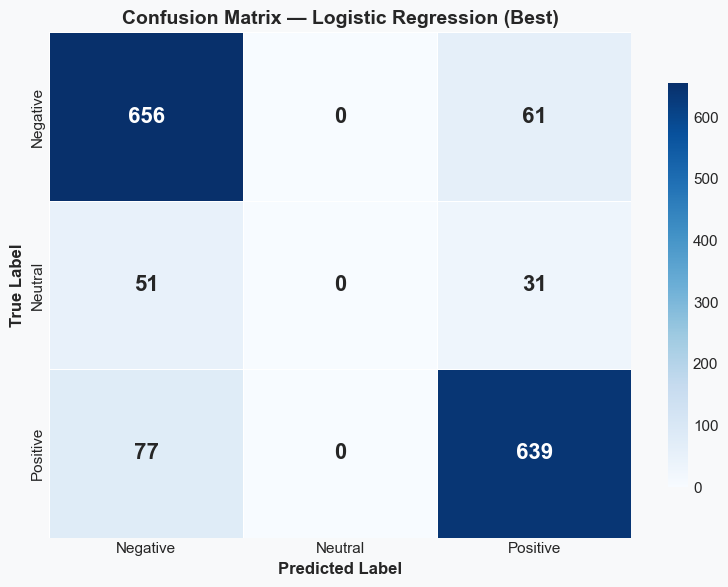

💾 Confusion matrix disimpan ke: static/images/confusion_matrix.png


In [38]:
# ── Confusion Matrix Model Terbaik (detail) ───────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

cm = best_result['confusion_matrix']

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels,
    ax=ax, linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 16, 'fontweight': 'bold'},
)

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix — {best_model_name} (Best)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('💾 Confusion matrix disimpan ke: static/images/confusion_matrix.png')

---

## ☁️ 11. Word Cloud & Top Keywords

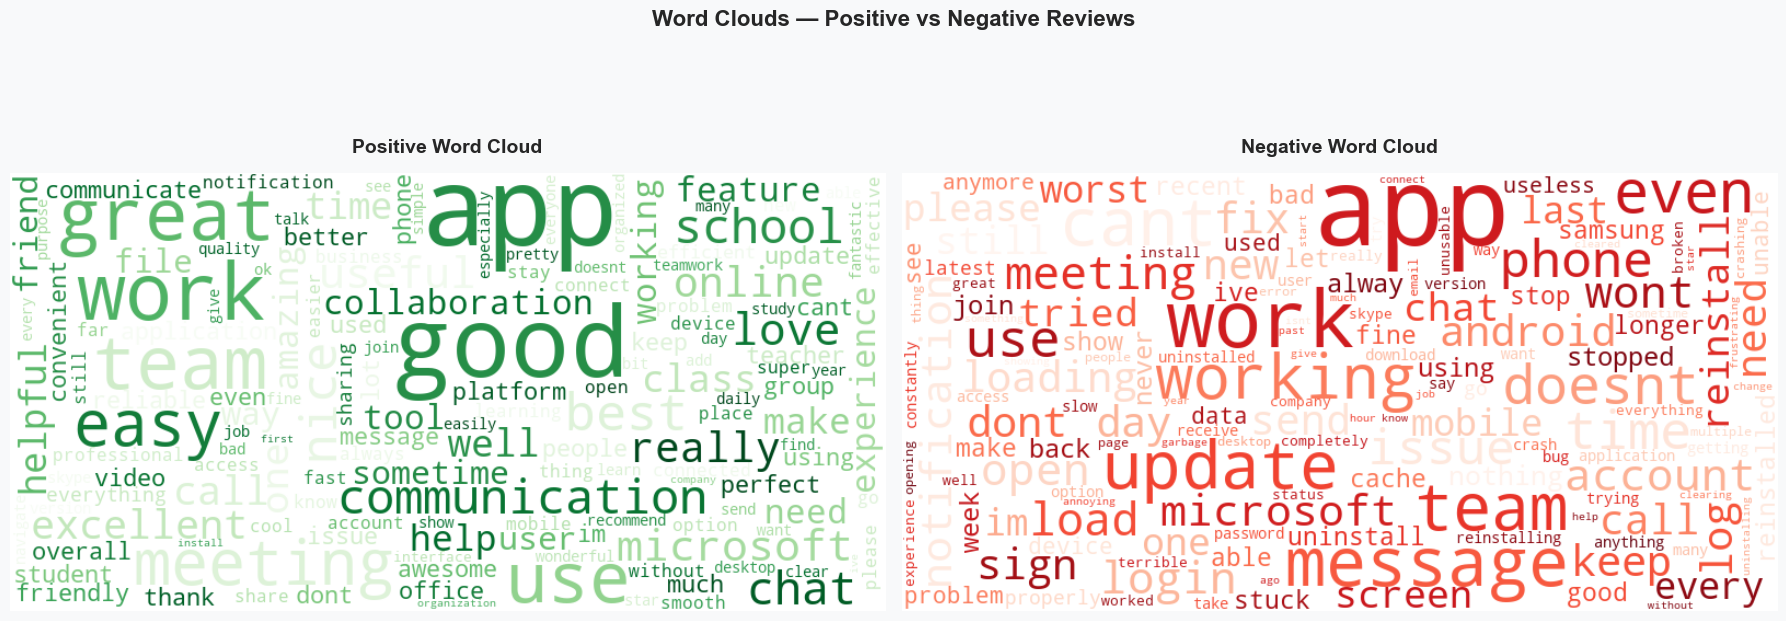

💾 Word clouds disimpan ke: static/wordcloud/


In [39]:
# ══════════════════════════════════════════════════════════════════════════
# 11.1 Word Clouds — Positive & Negative
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sentiments_wc = {
    'Positive': {'data': df[df['sentiment'] == 'Positive']['clean_review'], 'cmap': 'Greens', 'ax': axes[0]},
    'Negative': {'data': df[df['sentiment'] == 'Negative']['clean_review'], 'cmap': 'Reds', 'ax': axes[1]},
}

for sentiment, config in sentiments_wc.items():
    text = ' '.join(config['data'].dropna().values)
    
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=config['cmap'],
        max_words=150,
        max_font_size=100,
        random_state=RANDOM_STATE,
        collocations=False,
    )
    
    wc.generate(text)
    
    # Simpan file
    wc_path = os.path.join(WORDCLOUD_DIR, f'{sentiment.lower()}_wordcloud.png')
    wc.to_file(wc_path)
    
    # Tampilkan
    config['ax'].imshow(wc, interpolation='bilinear')
    config['ax'].axis('off')
    config['ax'].set_title(f'{sentiment} Word Cloud', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Word Clouds — Positive vs Negative Reviews', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💾 Word clouds disimpan ke: static/wordcloud/')

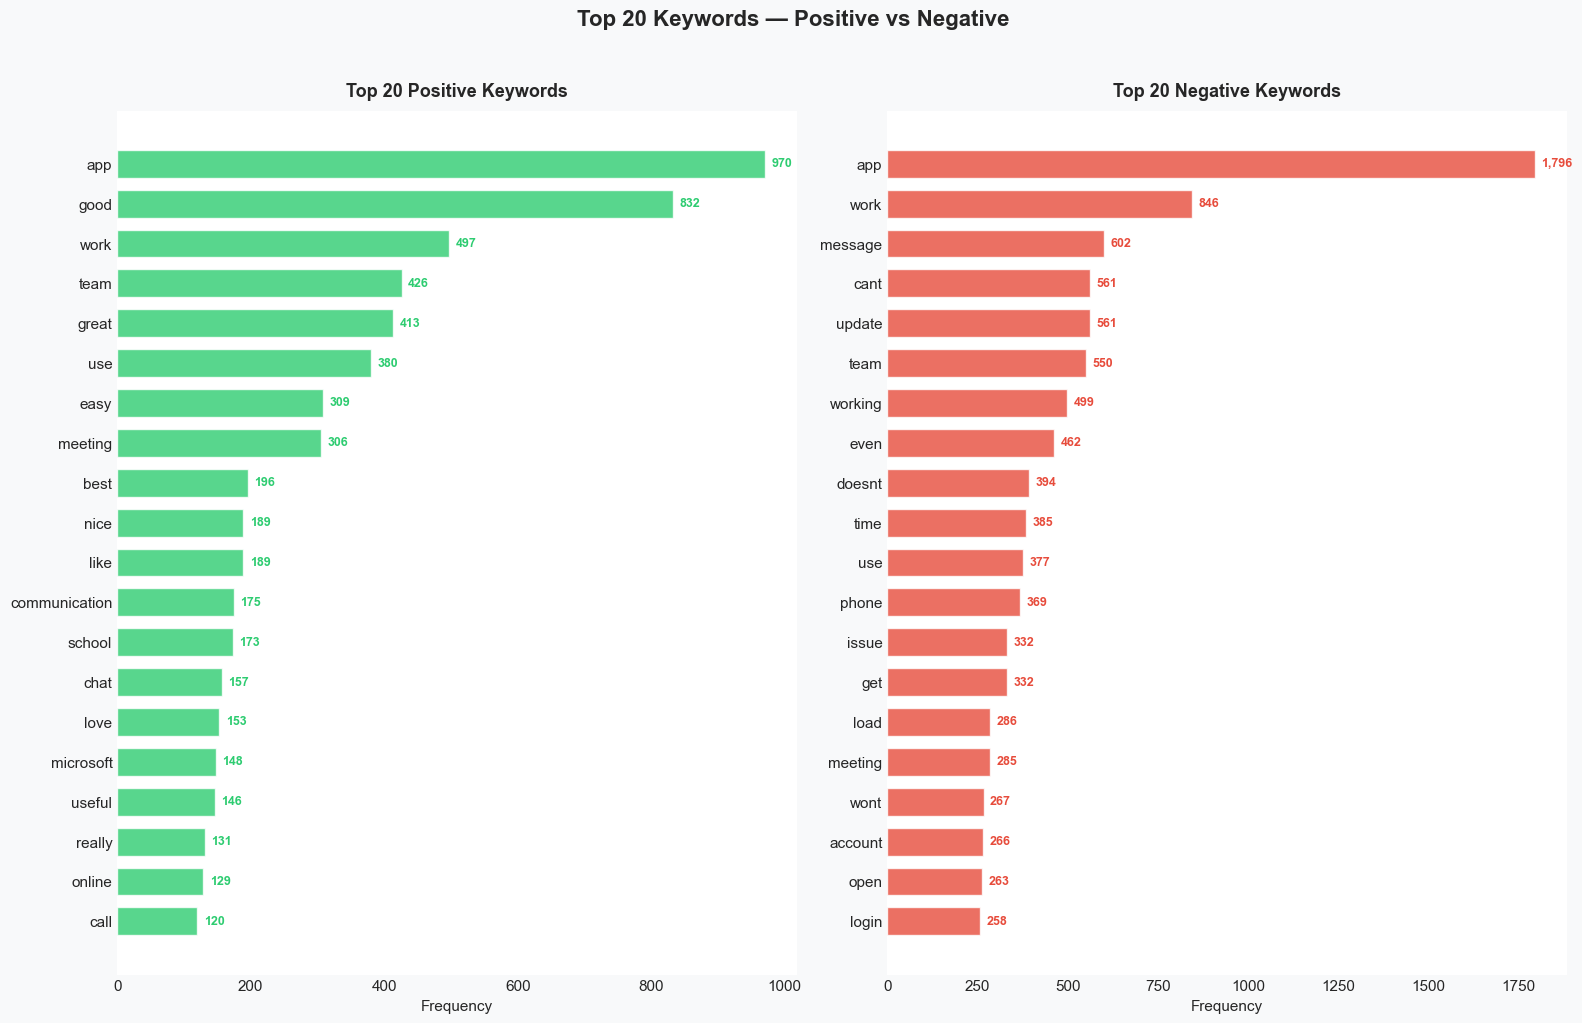

💾 Keywords disimpan ke: ..\models\keywords.json


In [40]:
# ══════════════════════════════════════════════════════════════════════════
# 11.2 Top 20 Keywords — Horizontal Bar Chart
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

keywords_data = {}

for idx, (sentiment, color) in enumerate([('Positive', '#2ecc71'), ('Negative', '#e74c3c')]):
    ax = axes[idx]
    
    reviews_text = df[df['sentiment'] == sentiment]['clean_review'].dropna()
    all_words = ' '.join(reviews_text.values).split()
    word_counts = Counter(all_words)
    top_20 = word_counts.most_common(20)
    
    keywords_data[sentiment.lower()] = [{'word': w, 'count': c} for w, c in top_20]
    
    words = [w for w, c in top_20][::-1]
    counts = [c for w, c in top_20][::-1]
    
    bars = ax.barh(words, counts, color=color, alpha=0.8, edgecolor='white', height=0.7)
    
    # Label
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                f'{count:,}', va='center', fontsize=9, fontweight='bold', color=color)
    
    ax.set_title(f'Top 20 {sentiment} Keywords', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Frequency', fontsize=11)

plt.suptitle('Top 20 Keywords — Positive vs Negative', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_DIR, 'top_keywords.png'), dpi=150, bbox_inches='tight')
plt.show()

# Simpan keywords JSON
keywords_path = os.path.join(MODELS_DIR, 'keywords.json')
with open(keywords_path, 'w') as f:
    json.dump(keywords_data, f, indent=2)
print(f'💾 Keywords disimpan ke: {keywords_path}')

---

## 💾 12. Save Model & Artifacts

Menyimpan model terbaik, TF-IDF vectorizer, dan metrik evaluasi untuk digunakan oleh Flask dashboard.

In [41]:
# ── Simpan Model Terbaik ──────────────────────────────────────────────────
model_path = os.path.join(MODELS_DIR, 'model.pkl')
joblib.dump(best_result['model'], model_path)
print(f'✅ Model disimpan   : {model_path}')

# ── Simpan TF-IDF Vectorizer ──────────────────────────────────────────────
tfidf_path = os.path.join(MODELS_DIR, 'tfidf.pkl')
joblib.dump(tfidf_vectorizer, tfidf_path)
print(f'✅ TF-IDF disimpan  : {tfidf_path}')

# ── Simpan Metrik Evaluasi ────────────────────────────────────────────────
metrics_save = {
    'best_model': best_model_name,
    'labels': class_labels,
    'models': {},
}

for name, res in results.items():
    metrics_save['models'][name] = {
        'accuracy': res['accuracy'],
        'precision': res['precision'],
        'recall': res['recall'],
        'f1_score': res['f1_score'],
        'classification_report': res['classification_report'],
    }

metrics_path = os.path.join(MODELS_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_save, f, indent=2)
print(f'✅ Metrics disimpan : {metrics_path}')

print(f'\n🎉 Semua artifact berhasil disimpan ke folder: {MODELS_DIR}/')

✅ Model disimpan   : ..\models\model.pkl
✅ TF-IDF disimpan  : ..\models\tfidf.pkl
✅ Metrics disimpan : ..\models\metrics.json

🎉 Semua artifact berhasil disimpan ke folder: ..\models/


---

## 🔮 13. Real-Time Prediction Demo

Menggunakan model terbaik yang sudah dilatih untuk memprediksi sentimen teks baru.

In [42]:
# ── Fungsi Prediksi ───────────────────────────────────────────────────────
def predict_sentiment(text, model, vectorizer):
    """
    Memprediksi sentimen dari teks menggunakan model yang sudah dilatih.
    
    Args:
        text (str): Teks review yang ingin diprediksi
        model: Model ML yang sudah dilatih
        vectorizer: TF-IDF vectorizer yang sudah di-fit
    
    Returns:
        dict: Hasil prediksi (sentiment, confidence, probabilities)
    """
    # 1. Preprocessing
    cleaned = clean_text(text)
    
    # 2. Vectorize
    features = vectorizer.transform([cleaned])
    
    # 3. Predict
    prediction = model.predict(features)[0]
    
    # 4. Probabilities
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(features)[0]
        classes = model.classes_
        prob_dict = {cls: round(float(p) * 100, 2) for cls, p in zip(classes, proba)}
        confidence = round(float(max(proba)) * 100, 2)
    else:
        prob_dict = {prediction: 100.0}
        confidence = 100.0
    
    return {
        'text': text,
        'cleaned': cleaned,
        'sentiment': prediction,
        'confidence': confidence,
        'probabilities': prob_dict,
    }

print('✅ Fungsi prediksi siap digunakan!')

✅ Fungsi prediksi siap digunakan!


In [43]:
# ── Demo Prediksi ────────────────────────────────────────────────────────
test_texts = [
    "This application is very useful for online collaboration.",
    "Terrible app! Keeps crashing during meetings. Very frustrating.",
    "It's okay, nothing special. Does the job but could be better.",
    "Love the screen sharing and chat features! Best collaboration tool.",
    "Audio quality is terrible, video freezes constantly. Waste of time.",
    "Decent app for meetings. Sometimes laggy but overall fine.",
    "The new update broke everything. Can't even login anymore!",
    "Amazing tool for remote work. Our team uses it every day!",
]

print('🔮 Demo Prediksi Sentimen:')
print('=' * 80)

best_model = best_result['model']

for i, text in enumerate(test_texts, 1):
    result = predict_sentiment(text, best_model, tfidf_vectorizer)
    
    # Emoji berdasarkan sentimen
    emojis = {'Positive': '😊', 'Neutral': '😐', 'Negative': '😞'}
    emoji = emojis.get(result['sentiment'], '🤔')
    
    print(f'\n  [{i}] "{text}"')
    print(f'      Sentiment  : {emoji} {result["sentiment"]}')
    print(f'      Confidence : {result["confidence"]}%')
    print(f'      Probabilities:')
    for label, prob in sorted(result['probabilities'].items()):
        bar = '█' * int(prob // 5) + '░' * (20 - int(prob // 5))
        print(f'         {label:10s}: [{bar}] {prob}%')

print('\n' + '=' * 80)

🔮 Demo Prediksi Sentimen:

  [1] "This application is very useful for online collaboration."
      Sentiment  : 😊 Positive
      Confidence : 93.86%
      Probabilities:
         Negative  : [░░░░░░░░░░░░░░░░░░░░] 4.97%
         Neutral   : [░░░░░░░░░░░░░░░░░░░░] 1.17%
         Positive  : [██████████████████░░] 93.86%

  [2] "Terrible app! Keeps crashing during meetings. Very frustrating."
      Sentiment  : 😞 Negative
      Confidence : 95.95%
      Probabilities:
         Negative  : [███████████████████░] 95.95%
         Neutral   : [░░░░░░░░░░░░░░░░░░░░] 1.56%
         Positive  : [░░░░░░░░░░░░░░░░░░░░] 2.5%

  [3] "It's okay, nothing special. Does the job but could be better."
      Sentiment  : 😊 Positive
      Confidence : 82.15%
      Probabilities:
         Negative  : [█░░░░░░░░░░░░░░░░░░░] 8.96%
         Neutral   : [█░░░░░░░░░░░░░░░░░░░] 8.89%
         Positive  : [████████████████░░░░] 82.15%

  [4] "Love the screen sharing and chat features! Best collaboration tool."
   

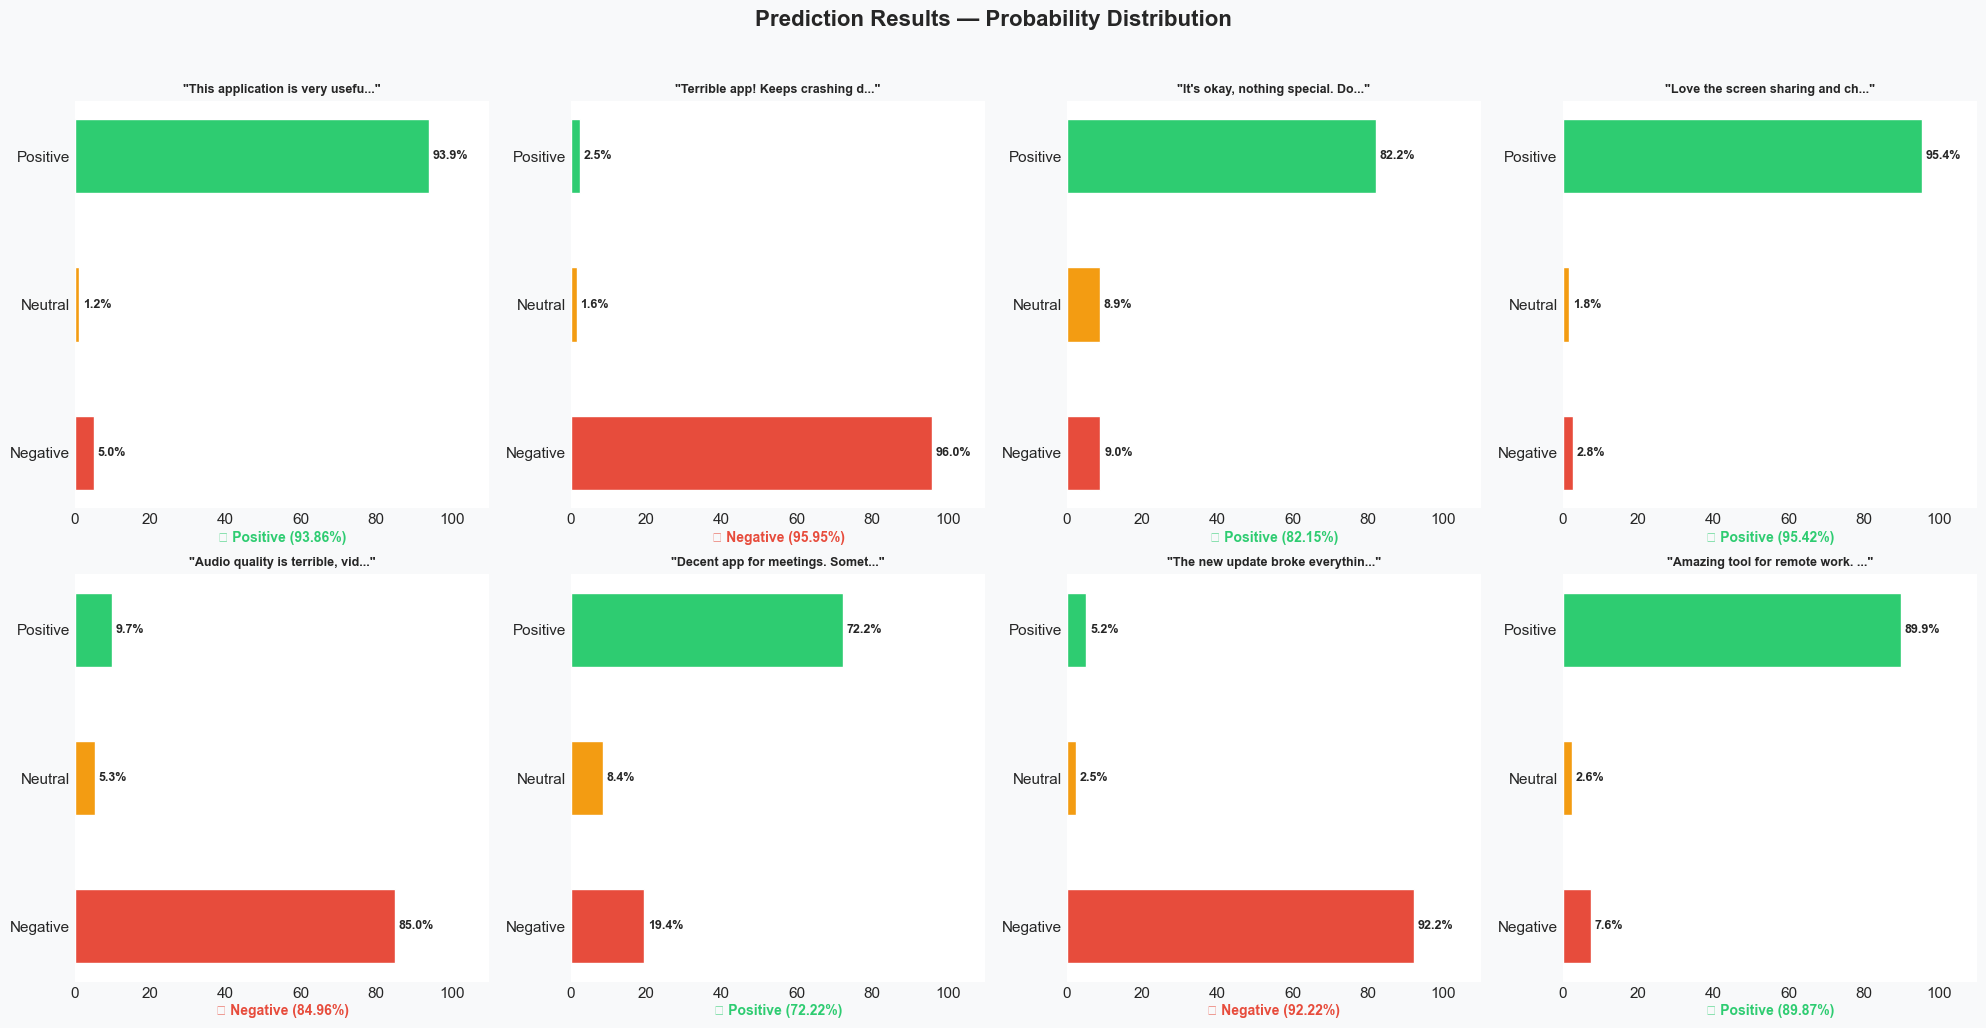

In [44]:
# ── Visualisasi Hasil Prediksi ────────────────────────────────────────────

# Prediksi semua test texts
pred_results = [predict_sentiment(t, best_model, tfidf_vectorizer) for t in test_texts]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

sentiment_colors_map = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

for idx, (result, ax) in enumerate(zip(pred_results, axes)):
    probs = result['probabilities']
    labels = list(probs.keys())
    values = list(probs.values())
    colors = [sentiment_colors_map.get(l, '#95a5a6') for l in labels]
    
    bars = ax.barh(labels, values, color=colors, edgecolor='white', height=0.5)
    
    # Label
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    
    ax.set_xlim(0, 110)
    ax.set_title(f'"{result["text"][:30]}..."', fontsize=9, fontweight='bold')
    
    # Highlight sentiment
    emoji = {'Positive': '😊', 'Neutral': '😐', 'Negative': '😞'}.get(result['sentiment'], '')
    ax.text(55, -0.6, f'{emoji} {result["sentiment"]} ({result["confidence"]}%)',
            fontsize=10, fontweight='bold', ha='center',
            color=sentiment_colors_map.get(result['sentiment'], 'gray'))

plt.suptitle('Prediction Results — Probability Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 📊 14. Ringkasan Akhir

Rangkuman lengkap dari seluruh proses analisis.

In [45]:
# ══════════════════════════════════════════════════════════════════════════
# RINGKASAN AKHIR
# ══════════════════════════════════════════════════════════════════════════

print('\n' + '🧠' + '═' * 68)
print('   NLP SENTIMENT ANALYSIS — RINGKASAN AKHIR')
print('═' * 70)

print(f'\n📱 Aplikasi        : {APP_NAME}')
print(f'📊 Total Reviews   : {len(df):,}')
print(f'⭐ Rata-rata Rating: {df["rating"].mean():.2f}')

print(f'\n📊 Distribusi Sentimen:')
for s in ['Positive', 'Neutral', 'Negative']:
    count = len(df[df['sentiment'] == s])
    pct = count / len(df) * 100
    print(f'   {s:10s}: {count:,} ({pct:.1f}%)')

print(f'\n🤖 Model Comparison:')
print(f'   {"Model":<30s} {"Accuracy":>10s} {"Precision":>10s} {"Recall":>10s} {"F1 Score":>10s}')
print(f'   {"-"*30} {"-"*10} {"-"*10} {"-"*10} {"-"*10}')
for name, res in results.items():
    marker = ' 👑' if name == best_model_name else '   '
    print(f'{marker}{name:<30s} {res["accuracy"]:>10.4f} {res["precision"]:>10.4f} {res["recall"]:>10.4f} {res["f1_score"]:>10.4f}')

print(f'\n🏆 Model Terbaik: {best_model_name}')
print(f'   F1 Score: {best_result["f1_score"]:.4f} ({best_result["f1_score"]*100:.2f}%)')

print(f'\n💾 File yang Dihasilkan:')
print(f'   📂 data/reviews.csv        — Dataset review')
print(f'   📦 models/model.pkl         — Model terbaik')
print(f'   📦 models/tfidf.pkl         — TF-IDF vectorizer')
print(f'   📦 models/metrics.json      — Metrik evaluasi')
print(f'   📦 models/keywords.json     — Top keywords')
print(f'   🖼️ static/images/           — Grafik evaluasi')
print(f'   ☁️ static/wordcloud/         — Word clouds')

print(f'\n🚀 Langkah Selanjutnya:')
print(f'   1. Jalankan dashboard: python app.py')
print(f'   2. Buka browser: http://localhost:5000')
print(f'   3. Coba Sentiment Checker: http://localhost:5000/checker')

print('\n' + '═' * 70)
print('✅ Notebook selesai! Semua model dan artifact sudah disimpan.')
print('═' * 70)


🧠════════════════════════════════════════════════════════════════════
   NLP SENTIMENT ANALYSIS — RINGKASAN AKHIR
══════════════════════════════════════════════════════════════════════

📱 Aplikasi        : Microsoft Teams
📊 Total Reviews   : 7,575
⭐ Rata-rata Rating: 2.97

📊 Distribusi Sentimen:
   Positive  : 3,579 (47.2%)
   Neutral   : 410 (5.4%)
   Negative  : 3,586 (47.3%)

🤖 Model Comparison:
   Model                            Accuracy  Precision     Recall   F1 Score
   ------------------------------ ---------- ---------- ---------- ----------
 👑Logistic Regression                0.8548     0.8091     0.8548     0.8311
   Multinomial Naive Bayes            0.8469     0.8036     0.8469     0.8235
   Random Forest                      0.8376     0.8113     0.8376     0.8158

🏆 Model Terbaik: Logistic Regression
   F1 Score: 0.8311 (83.11%)

💾 File yang Dihasilkan:
   📂 data/reviews.csv        — Dataset review
   📦 models/model.pkl         — Model terbaik
   📦 models/tfidf.pkl   